# Detection — run & evaluate

Thin runner for the full cascade (L1 Stage1 → L2 Consolidator → L3 Classifier → L4 event decision). Fits
on **all 100 recordings**, checks the L3 window centring, saves the model. All logic lives in `src/`
(`detect_config`, `detect_data`, `detection`, `detect_metrics`); this notebook just wires it together.

**There is no held-out test set** (`cfg.n_test = 0`). The 10-recording holdout held only ~5 IEDs, so its
sensitivity moved in steps of 0.2 and it was never used for a decision — those recordings now train the
model instead. **The grouped cross-validation below is the single performance estimate**, over 54 IEDs.
Its cost is stated in report.md: the L4 arms and L3 hyperparameters were selected on this same CV, and
nothing independent now checks that optimism.

**~5 min for the main path** (the L3 registration fit dominates; L1+L2 over all 100 recordings is ~8 s).


In [1]:
%load_ext autoreload
%autoreload 2
# ^ re-imports src/ on every cell run. Without it, editing detect_config.py or detect_metrics.py has no
#   effect until the kernel is restarted — silently, so a changed setting looks like it "did nothing".

import sys
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
from detect_data import load_dataset, stratified_split
from detection import Config, DetectionPipeline
import detect_metrics as M
import detect_plots as P

cfg = Config()
man = load_CSV(Path('..') / 'Kural_Dataset' / 'eeg_summary.csv')
train_df, _ = stratified_split(man, n_test=cfg.n_test, seed=cfg.split_seed)   # n_test=0: all 100 train
REC = Path('..') / 'Kural_Dataset' / 'Recordings'
train = load_dataset(train_df, REC, cfg)   # pass cfg: preprocessing must match what the model is
print(f"{len(train)} recordings, {sum(r['epi'] for r in train)} IEDs — no held-out split")
print(f"preprocess: {cfg.sfreq:.0f} Hz  bandpass={cfg.bandpass}  reference={cfg.reference!r}  "
      f"bad soft/hard={cfg.bad_soft_factor}/{cfg.bad_hard_factor}x cap={cfg.max_interpolate}")
print(f"model: grouping={cfg.grouping!r} corr={cfg.corr_threshold} centre_on={cfg.centre_on!r} "
      f"n_basis={cfg.n_basis} k={cfg.n_components} registration={cfg.registration!r} "
      f"polarity={cfg.polarity_feature} spatial={cfg.spatial_feature}")
bad = [(r["fid"], r["bad_soft"], r["bad_hard"]) for r in train if r["bad_soft"] or r["bad_hard"]]
print(f"bad channels flagged in {len(bad)} of {len(train)} recordings: {bad}")

pipe = DetectionPipeline(cfg).fit(train)     # trains L3 on consolidated TRAIN candidates only
print('fit:', pipe.train_stats_)
if pipe.l4 is not None:                      # L4 event decision: (L3 score, n_channels)
    print('L4 weights [score, n_channels]:', pipe.l4[1].coef_[0].round(3))
pipe.save('../detect_model.joblib')          # shippable model (Config + fitted classifier)

100 recordings, 54 IEDs — no held-out split
preprocess: 250 Hz  bandpass=(0.5, 45.0)  reference='average'  bad soft/hard=3.0/10.0x cap=2
model: grouping='components' corr=0.7 centre_on='amplitude' n_basis=70 k=24 registration='elastic' polarity=True spatial=True
bad channels flagged in 1 of 100 recordings: [('S49', [16], [])]
fit: {'windows': 4608, 'positives': 65}
L4 weights [score, n_channels]: [0.809 0.617 0.327]


## Window centring check (TRAIN only)

`event_window` re-centres each event before cutting the 2 s window the classifier sees. That choice is
potentially load-bearing: **Fisher-Rao registration is alignment-sensitive**, so if the re-centring lands
on the wrong extremum — an after-going slow wave, a baseline drift, the biphasic down-stroke — every FDA
feature is computed on a shifted curve, and L3's AUC would be depressed for a reason that has nothing to
do with the model. This section tests that.

`cfg.centre_on` picks the rule:
- `'amplitude'` — max |deviation from the local median| of the smoothed signal. Matches the annotation
  convention (marker at the spike peak) and how the classification-phase windows were cut, but the
  *largest* deflection near a spike is often the slow after-going component, not the spike.
- `'sharpness'` — max of the L1 statistic (|SG 2nd deriv| / MAD). Curvature peaks at the apex of a sharp
  transient, so a slow wave can't win.

Offsets below are measured against the **neurologist marker** (0 ms = the window centre sits exactly on
the annotated spike peak), over all 100 recordings only.

In [2]:
import numpy as np, matplotlib.pyplot as plt
from dataclasses import replace

off = {}                                  # centring rule -> (positive windows, offsets ms, recording ids)
for mode in ('amplitude', 'sharpness'):
    off[mode] = M.centring_offsets(DetectionPipeline(replace(cfg, centre_on=mode)), train)
    a = np.abs(off[mode][1])
    print(f"centre_on={mode:<10s} n={len(a):3d}   |offset| median {np.median(a):3.0f} ms  "
          f"p90 {np.percentile(a, 90):3.0f} ms  max {a.max():3.0f} ms   >100 ms: {(a > 100).mean():.0%}")

centre_on=amplitude  n= 65   |offset| median  32 ms  p90 144 ms  max 184 ms   >100 ms: 23%
centre_on=sharpness  n= 65   |offset| median  16 ms  p90  65 ms  max 100 ms   >100 ms: 0%


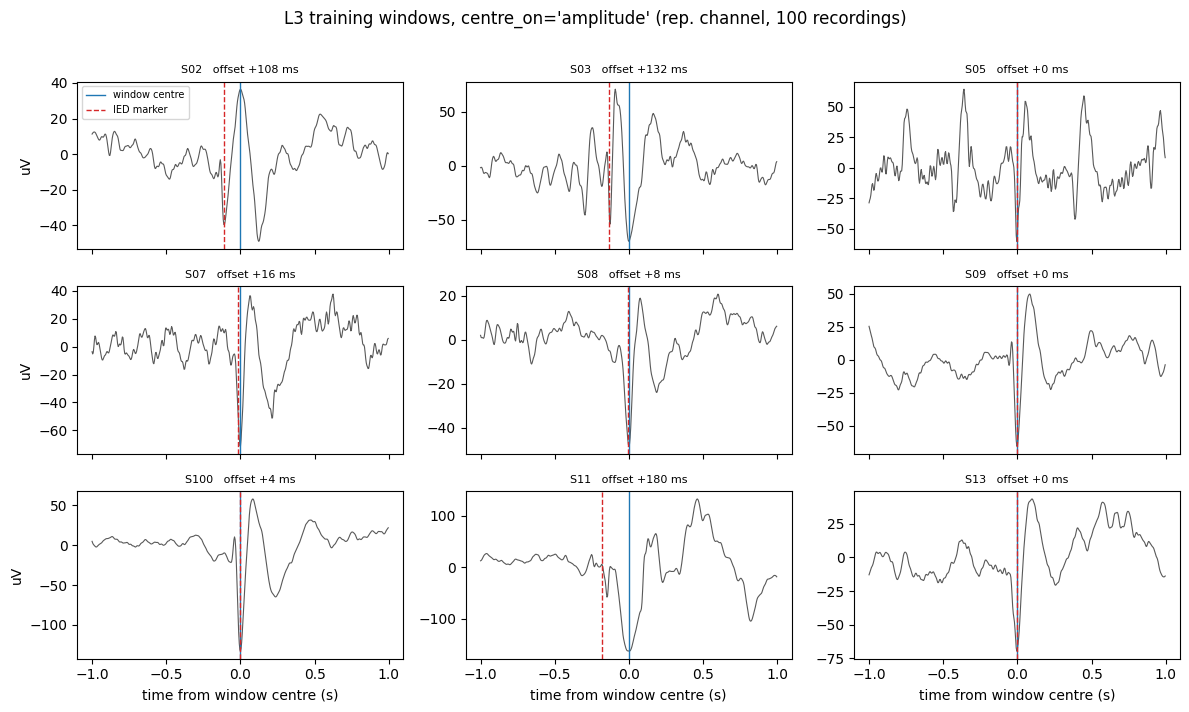

In [3]:
# eyeball 9 IED windows (one per recording) under the configured rule: centre should sit on the marker
W, offs, fids = off[cfg.centre_on]
seen, pick = set(), []
for i, f in enumerate(fids):
    if f not in seen:
        seen.add(f); pick.append(i)
t = (np.arange(W.shape[1]) - W.shape[1] // 2) / cfg.sfreq

fig, axs = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
for ax, i in zip(axs.ravel(), pick[:9]):
    ax.plot(t, W[i], lw=0.8, color='0.35')
    ax.axvline(0, color='C0', lw=1.0, label='window centre')
    ax.axvline(-offs[i] / 1000, color='C3', ls='--', lw=1.0, label='IED marker')
    ax.set_title(f"{fids[i]}   offset {offs[i]:+.0f} ms", fontsize=8)
axs[0, 0].legend(fontsize=7, loc='upper left')
for ax in axs[-1]:
    ax.set_xlabel('time from window centre (s)')
for ax in axs[:, 0]:
    ax.set_ylabel('uV')
plt.suptitle(f"L3 training windows, centre_on='{cfg.centre_on}' (rep. channel, 100 recordings)", y=1.01)
plt.tight_layout()
plt.savefig(f'../figures/detection_window_centring_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

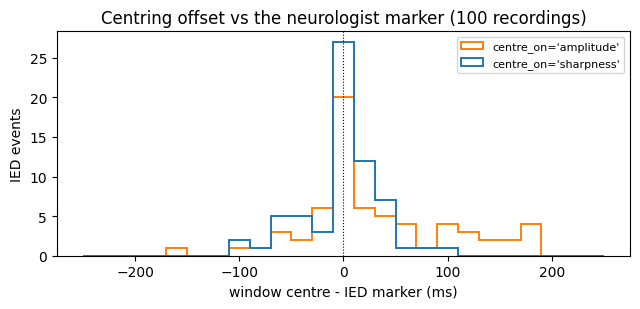

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
for mode, c in (('amplitude', 'C1'), ('sharpness', 'C0')):
    ax.hist(off[mode][1], bins=np.arange(-250, 251, 20), histtype='step', lw=1.4, color=c,
            label=f"centre_on='{mode}'")
ax.axvline(0, color='k', ls=':', lw=0.8)
ax.set_xlabel('window centre - IED marker (ms)'); ax.set_ylabel('IED events')
ax.set_title('Centring offset vs the neurologist marker (100 recordings)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/detection_centring_offsets.png', dpi=800, bbox_inches='tight')
plt.show()

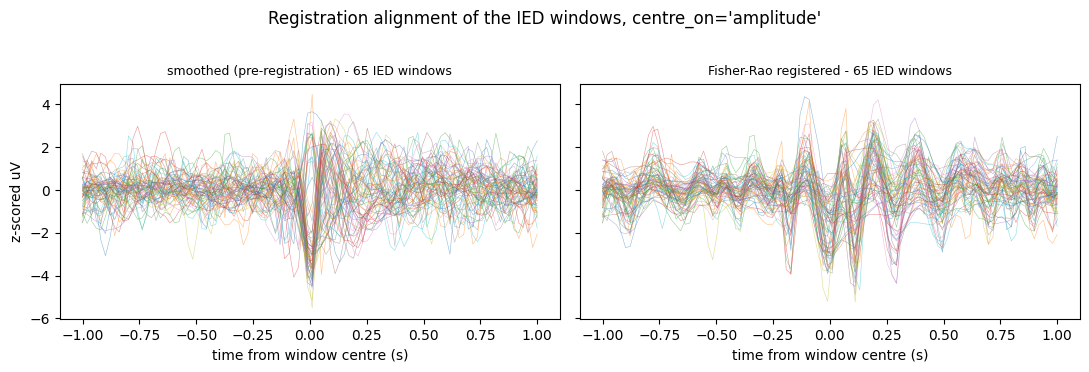

In [5]:
# do the positive windows stack once registered? (the curves the LR actually sees)
sm, al = pipe.classifier.aligned_curves(off[cfg.centre_on][0])
z = lambda A: (A - A.mean(1, keepdims=True)) / (A.std(1, keepdims=True) + 1e-12)
tt = np.linspace(-cfg.classifier_halfwin_s, cfg.classifier_halfwin_s, sm.shape[1])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, A, ttl in ((axs[0], sm, 'smoothed (pre-registration)'), (axs[1], al, 'Fisher-Rao registered')):
    ax.plot(tt, z(A).T, lw=0.4, alpha=0.5)
    ax.set_title(f"{ttl} - {len(A)} IED windows", fontsize=9)
    ax.set_xlabel('time from window centre (s)')
axs[0].set_ylabel('z-scored uV')
plt.suptitle(f"Registration alignment of the IED windows, centre_on='{cfg.centre_on}'", y=1.02)
plt.tight_layout()
plt.savefig(f'../figures/detection_registration_alignment_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

## Grouped cross-validation on all 100 recordings (run on demand)

**This is where every result is read from.** Folds are **grouped by recording**, so the several events
one IED spawns never land on both sides of a split, and pooling the out-of-fold scores gives a FROC over
all 54 IEDs.

It evaluates **the shipped pipeline**, not just L3: when `cfg.spatial_feature` is on, the L4 decision
(L3 score + `n_channels` + `dipole`) is refitted inside each fold and the FROC, AUC, PR-AUC and operating
point below are computed from those scores. The L3-only scores stay available in `cv['scores']`.

The operating point is derived, not chosen: `cfg.fp_budget` fixes the false-positive rate — an external
criterion, clinical review burden or comparability with published detectors at 0.5–5 FP/min — and the
threshold is whatever the FROC gives at that budget.

**Independent cell:** nothing else depends on it. Set `RUN_GROUPED_CV = True` to run
(~15–20 min: one full L3 fit per fold).


L4 applied (score + n_channels + dipole); L3-only scores remain in cv['scores']
grouped-CV AUC 0.865  95% CI [0.793, 0.935]   PR-AUC 0.363
per fold        0.831 · 0.914 · 0.844 · 0.894 · 0.853
windows 4608, positives 65, localisation median 8 ms over 53 IEDs
cross-validated FROC — best sensitivity at FP/min budget:
    <=   1 FP/min : sens 0.35
    <=   5 FP/min : sens 0.70
    <=  10 FP/min : sens 0.80
    <=  25 FP/min : sens 0.87
    <=  50 FP/min : sens 0.93
    <= 100 FP/min : sens 0.96
operating point @ <= 10 FP/min (score >= 0.766): hits 43/54  misses 11  false positives 198 (9.4/min)


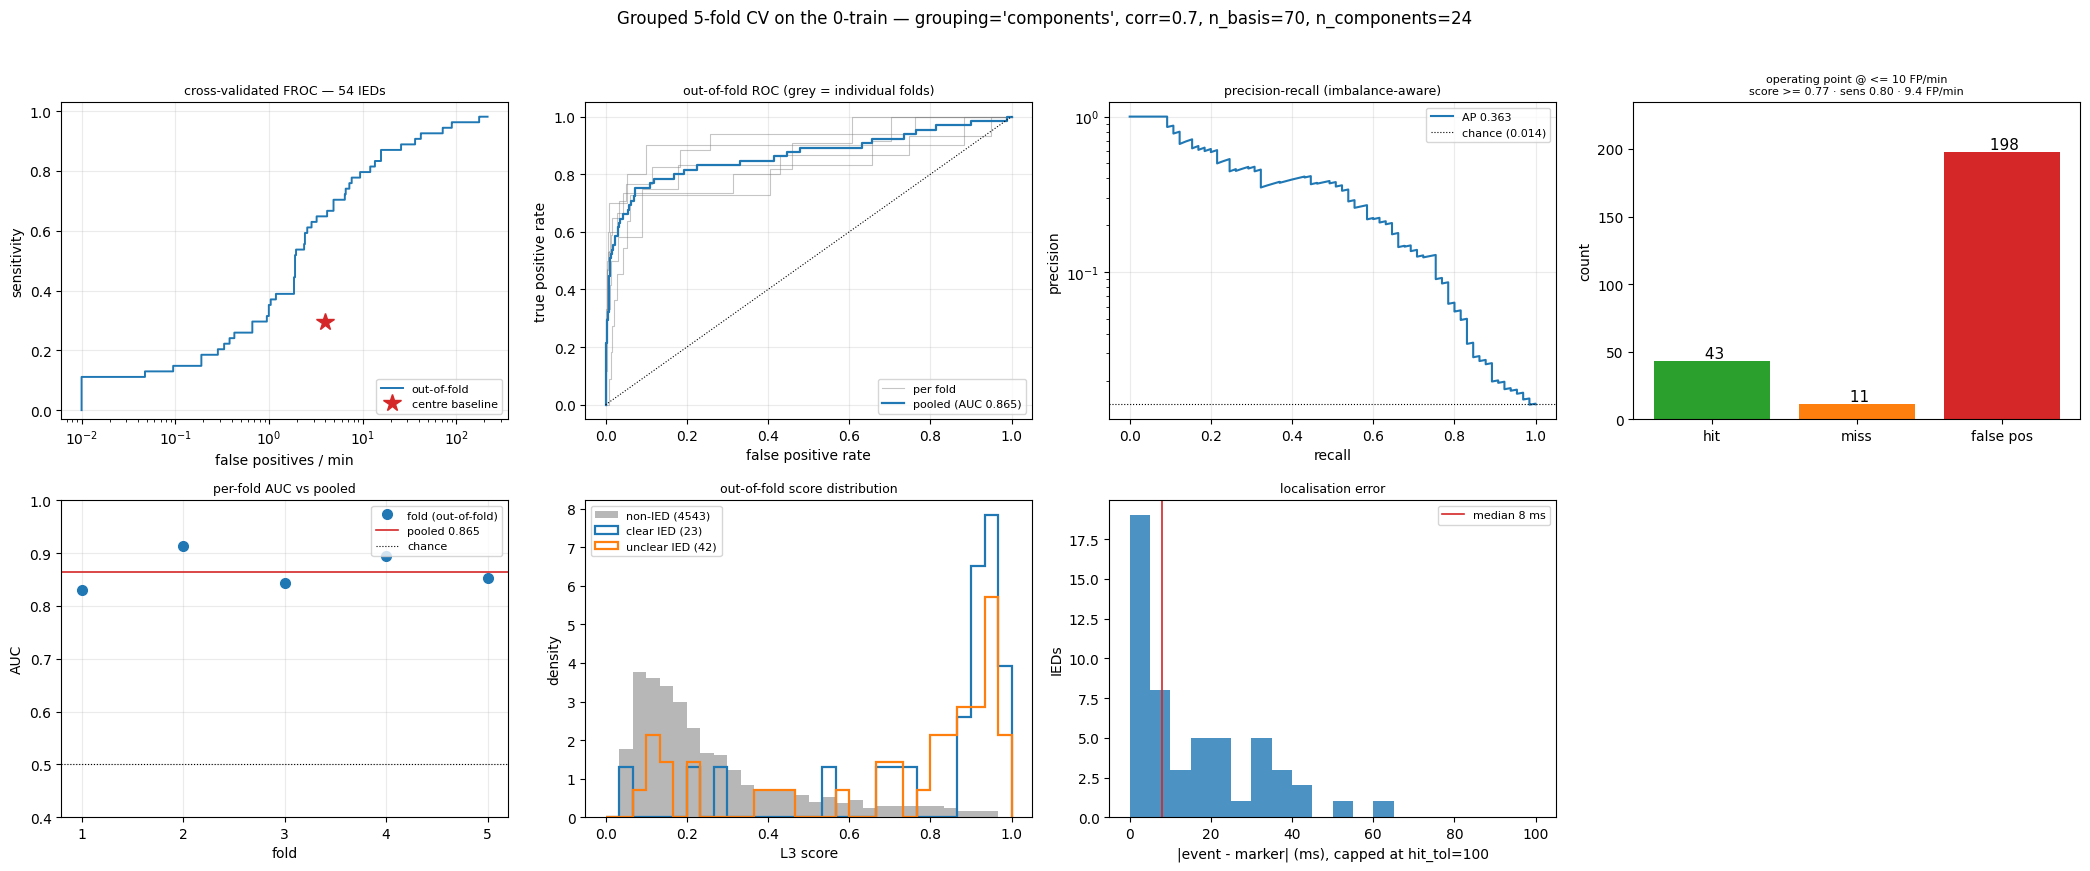

In [15]:
RUN_GROUPED_CV = True         # ~15-20 min (one L3 fit per fold). Nothing below depends on this cell.

if RUN_GROUPED_CV:
    cv = M.grouped_cv(pipe, train)                       # out-of-fold L3 scores over every candidate
    s_final = cv['scores']
    if cfg.spatial_feature:      # evaluate what is SHIPPED: L4 refitted inside the same folds
        from sklearn.linear_model import LogisticRegression
        from sklearn.preprocessing import StandardScaler
        from detect_data import electrode_positions
        from detection import _smooth, spatial_features
        pos = electrode_positions()
        Xsm = {g: _smooth(train[g]['X'], cfg) for g in set(cv['G'].tolist())}
        S = np.array([[spatial_features(e, Xsm[g], cfg, pos)[n] for n in ('n_channels', 'dipole')]
                      for e, g in zip(cv['events'], cv['G'])], float)
        F4 = np.column_stack([cv['scores'], S])
        s_final = np.zeros(len(cv['Y']))
        for kf in np.unique(cv['fold']):
            tr4, te4 = cv['fold'] != kf, cv['fold'] == kf
            sk = StandardScaler().fit(F4[tr4])
            l4 = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            l4.fit(sk.transform(F4[tr4]), cv['Y'][tr4])
            s_final[te4] = l4.predict_proba(sk.transform(F4[te4]))[:, 1]
        cv['l4'] = s_final
        print(f"L4 applied (score + n_channels + dipole); L3-only scores remain in cv['scores']")
    from sklearn.metrics import average_precision_score, roc_auc_score
    auc_f = roc_auc_score(cv['Y'], s_final)                 # of the scores actually shipped
    ap_f = average_precision_score(cv['Y'], s_final)
    folds_f = [roc_auc_score(cv['Y'][cv['fold'] == k], s_final[cv['fold'] == k])
               for k in range(len(cv['folds']))]
    lo, hi = M.bootstrap_auc_ci(cv['Y'], cv['G'], s_final)
    pts = M.froc_points(train, cv['events'], cv['G'], s_final, cfg)
    errs = M.localisation_errors(train, cv['events'], cv['G'], s_final, cfg)
    cm = M.detection_counts(train, cv['events'], cv['G'], s_final, cfg,
                            M.threshold_at(pts, cfg.fp_budget))
    print(f"grouped-CV AUC {auc_f:.3f}  95% CI [{lo:.3f}, {hi:.3f}]   PR-AUC {ap_f:.3f}")
    print(f"per fold        {' · '.join(f'{f:.3f}' for f in folds_f)}")
    print(f"windows {len(cv['Y'])}, positives {cv['Y'].sum()}, "
          f"localisation median {np.median(errs):.0f} ms over {len(errs)} IEDs")
    print('cross-validated FROC — best sensitivity at FP/min budget:')
    for fp, sens in M.froc_summary(pts).items():
        print(f'    <= {fp:>3} FP/min : sens {sens:.2f}')
    print(f"operating point @ <= {cfg.fp_budget:.0f} FP/min "
          f"(score >= {cm['threshold']:.3f}): hits {cm['hit']}/{cm['hit'] + cm['miss']}  "
          f"misses {cm['miss']}  false positives {cm['fp']} ({cm['fp_per_min']:.1f}/min)")

    fig, axs = plt.subplots(2, 4, figsize=(21, 8.5))
    P.froc(axs[0, 0], pts, label='out-of-fold', baseline=M.centre_baseline(train, cfg))
    axs[0, 0].set_title(f"cross-validated FROC — {sum(r['epi'] for r in train)} IEDs", fontsize=9)
    P.roc(axs[0, 1], cv['Y'], s_final,
          folds=[(cv['Y'][cv['fold'] == k], s_final[cv['fold'] == k])
                 for k in range(len(folds_f))])
    axs[0, 1].set_title('out-of-fold ROC (grey = individual folds)', fontsize=9)
    P.pr(axs[0, 2], cv['Y'], s_final)
    axs[0, 2].set_title('precision-recall (imbalance-aware)', fontsize=9)
    P.counts(axs[0, 3], cm, f'operating point @ <= {cfg.fp_budget:.0f} FP/min')
    P.fold_aucs(axs[1, 0], folds_f, auc_f)
    axs[1, 0].set_title('per-fold AUC vs pooled', fontsize=9)
    P.score_hist(axs[1, 1], cv['Y'], s_final, cv['G'], train)
    axs[1, 1].set_title('out-of-fold score distribution', fontsize=9)
    P.loc_error(axs[1, 2], errs, cfg)
    axs[1, 2].set_title('localisation error', fontsize=9)
    axs[1, 3].axis('off')
    plt.suptitle(f"Grouped 5-fold CV on the 0-train — grouping='{cfg.grouping}', "
                 f"corr={cfg.corr_threshold}, n_basis={cfg.n_basis}, n_components={cfg.n_components}",
                 y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/detection_grouped_cv.png', dpi=800, bbox_inches='tight')
    plt.show()

In [6]:
# n_components sweep. Registration is fitted ONCE per fold and reused, so every k after that is ~free.
n_components_sweep = False

if n_components_sweep:
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    KS = [2, 4, 6, 8, 12, 16, 24, 32]
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    scores = {k: np.zeros(len(Y)) for k in KS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=max(KS)).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        for k in KS:
            sc = StandardScaler().fit(P_tr[:, :k])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(P_tr[:, :k]), Y[tr])
            scores[k][te] = lr.predict_proba(sc.transform(P_te[:, :k]))[:, 1]
        print(f'fold {f} done', flush=True)

    print(f"{'k':>4} {'AUC':>7} {'95% CI':>18} {'sens@10':>8} {'sens@25':>8} {'sens@50':>8}")
    for k in KS:
        lo, hi = M.bootstrap_auc_ci(Y, G, scores[k], n_boot=500)
        fs = M.froc_summary(M.froc_points(train, E, G, scores[k], cfg))
        print(f"{k:>4} {roc_auc_score(Y, scores[k]):>7.3f}   [{lo:.3f}, {hi:.3f}]   "
            f"{fs[10]:>8.2f} {fs[25]:>8.2f} {fs[50]:>8.2f}")


In [7]:
if n_components_sweep:
    import joblib; joblib.dump({'KS': KS, 'scores': scores, 'Y': Y, 'G': G}, '/tmp/sweep_ncomp.joblib')
    for k in (4, 12, 16, 24, 32):
        fs = M.froc_summary(M.froc_points(train, E, G, scores[k], cfg))
        print(f"k={k:>3}  " + "  ".join(f"@{b}:{fs[b]:.2f}" for b in (1, 5, 10, 25, 50, 100)))
    print("centre baseline:", M.centre_baseline(train, cfg))


In [8]:
n_basis_sweep = False

if n_basis_sweep:

    from dataclasses import replace
    import joblib
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier
    BASES, KS = [30, 50, 70, 100], [8, 12, 16, 24, 32]
    E, W, Y, G = M.labelled_events(pipe, train)      # L1/L2 are independent of n_basis
    sweep = {}
    print(f"{'n_basis':>7} {'k':>4} {'AUC':>7} {'@5':>6} {'@10':>6} {'@25':>6}")
    for b in BASES:
        c = replace(cfg, n_basis=b)
        clf, ks = Classifier(c), [k for k in KS if k <= b - 2]   # can't keep more components than basis fns
        sc = {k: np.zeros(len(Y)) for k in ks}
        for tr, te in GroupKFold(n_splits=5).split(W, Y, G):
            fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
            reg = FisherRaoElasticRegistration(penalty=c.penalty).fit(fds_tr)
            al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
            fpca = FPCA(n_components=max(ks)).fit(al_tr)
            P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
            for k in ks:
                s = StandardScaler().fit(P_tr[:, :k])
                lr = LogisticRegression(C=c.lr_C, max_iter=1000, class_weight='balanced')
                lr.fit(s.transform(P_tr[:, :k]), Y[tr])
                sc[k][te] = lr.predict_proba(s.transform(P_te[:, :k]))[:, 1]
        for k in ks:
            fs = M.froc_summary(M.froc_points(train, E, G, sc[k], cfg), fp_targets=(5, 10, 25))
            print(f"{b:>7} {k:>4} {roc_auc_score(Y, sc[k]):>7.3f} {fs[5]:>6.2f} {fs[10]:>6.2f} "
                f"{fs[25]:>6.2f}", flush=True)
        sweep[b] = sc
    joblib.dump({'sweep': sweep, 'Y': Y, 'G': G}, '/tmp/sweep_basis.joblib')


In [9]:
# hard-negative-mining sweep. Mining only changes which rows the LR trains on, and it sits AFTER
# registration + FPCA, so every ratio shares one CV run — the same trick as the n_components sweep.
hard_neg_sweep = False

if hard_neg_sweep:
    from dataclasses import replace
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    RATIOS = [0, 2, 5, 10, 20, 50]        # hardest negatives kept per positive; 0 = keep all (current)
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    sc = {r: np.zeros(len(Y)) for r in RATIOS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        fpca = FPCA(n_components=cfg.n_components).fit(reg.transform(fds_tr))
        P_tr, P_te = fpca.transform(reg.transform(fds_tr)), fpca.transform(reg.transform(fds_te))
        s = StandardScaler().fit(P_tr)
        Z_tr, Z_te = s.transform(P_tr), s.transform(P_te)
        lr0 = clf._fit_lr(Z_tr, Y[tr])                      # first pass: all negatives
        for r in RATIOS:
            if r == 0:
                lr = lr0
            else:
                c = Classifier(replace(cfg, hard_neg_ratio=r))
                c._lr = lr0                                  # mine against the first-pass ranking
                lr = c._fit_lr(*c._mine(Z_tr, Y[tr]))
            sc[r][te] = lr.predict_proba(Z_te)[:, 1]
        print(f'fold {f} done', flush=True)

    print(f"\n{'ratio':>6} {'ROC-AUC':>8} {'PR-AUC':>7} {'@5':>6} {'@10':>6} {'@25':>6}   "
          f"hits/misses/FP @ <= {cfg.fp_budget:.0f} FP/min")
    for r in RATIOS:
        pts = M.froc_points(train, E, G, sc[r], cfg)
        fs = M.froc_summary(pts, fp_targets=(5, 10, 25))
        c = M.detection_counts(train, E, G, sc[r], cfg, M.threshold_at(pts, cfg.fp_budget))
        print(f"{r:>6} {roc_auc_score(Y, sc[r]):>8.3f} {average_precision_score(Y, sc[r]):>7.3f} "
              f"{fs[5]:>6.2f} {fs[10]:>6.2f} {fs[25]:>6.2f}   "
              f"{c['hit']:>3} / {c['miss']:>3} / {c['fp']:>4}")
    print(f"(PR-AUC chance = {Y.mean():.3f};  centre baseline "
          f"{M.centre_baseline(train, cfg)[0]:.2f} @ {M.centre_baseline(train, cfg)[1]:.1f} FP/min)")


In [10]:
# paired bootstrap of the mining gain — needs `sc`/`Y`/`G` from the sweep cell above
if hard_neg_sweep:
    from sklearn.metrics import average_precision_score
    rng, groups, d = np.random.default_rng(0), np.unique(G), []
    for _ in range(2000):
        idx = np.concatenate([np.where(G == k)[0] for k in rng.choice(groups, len(groups), replace=True)])
        if len(set(Y[idx].tolist())) > 1:
            d.append(average_precision_score(Y[idx], sc[20][idx])
                     - average_precision_score(Y[idx], sc[0][idx]))
    d = np.array(d)
    print(f"PR-AUC(ratio 20) - PR-AUC(all): {d.mean():+.3f}  "
          f"95% CI [{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]  P(>0)={np.mean(d > 0):.2f}")


## Error analysis — where the detector fails, and why

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

Both failure modes matter, and the misses are the more informative half. The interesting property is that
**nearly all misses are L3 ranking failures** — L1 and L2 recall are high enough that almost every IED
already has a near-marker event in the candidate pool, so the front end did its job and L3 scored the
event too low. That gives clean attribution: one place to look, not three. (The exception is any IED whose
event is captured but *timestamped* outside the hit tolerance — see deferred item I in report.md §8.)

The analysis runs in three phases, cheapest and most decision-changing first.

**Phase 1 (below) — bookkeeping on the out-of-fold scores. No refitting, seconds to run.**
- **Q1 · hits and misses by certainty.** If the detector finds most `clear_positive` IEDs and fails on
  `unclear_positive` ones, "59% at 10 FP/min" becomes something like "85% of clear, 40% of unclear" — a
  more honest headline, with the failures on cases the neurologists themselves hedged about.
- **Q2 · how badly are the misses missed?** For each missed IED, how many extra false positives you would
  have to accept to catch it. A few just below threshold means small gains recover several IEDs; a long
  tail means those IEDs are a different population and no threshold change reaches them.
- **Q3 · are the false positives concentrated?** If a handful of noisy recordings generate most of them,
  the fix is per-recording amplitude normalisation and has nothing to do with spatial features. If they
  are spread evenly, it is a genuine morphology problem and L4 is the right tool. Different diagnoses,
  completely different work.
- **Q4 · do FPs come from negative or from epileptic recordings?** Both are true false positives (epileptic
  recordings are verified single-IED, so all non-marker EEG is IED-free), but a skew toward epileptic
  recordings points at something recording-level rather than a generic mimic problem.

**Phase 2 — qualitative.** Plot the top false positives and the missed IEDs and classify them by eye:
muscle, eye blink, sharp alpha, electrode pop, or a genuine-looking discharge that was never marked. That
last category is the important one — if the top FPs look like real IEDs, the ceiling is the label set
rather than the model, and that is a finding about the data.

**Phase 3 — the spatial-feature separation test.** Compute candidate L4 features (largest spatially
connected cluster, polarity split across the field, amplitude-gradient smoothness) for exactly the hits
and false positives at the operating point, and measure univariate separation. **Kill criterion, stated in advance:** if no
single feature reaches a univariate AUC of about 0.65 on that comparison, L4 cannot rescue these false
positives, and spatial features get reported as tested-and-rejected alongside centring and hard-negative
mining.

In [11]:
# Phase 1 — error analysis on the out-of-fold CV scores. No refitting: pure bookkeeping.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    tol = cfg.samp(cfg.hit_tol_ms)
    pts = M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg)
    thr = M.threshold_at(pts, cfg.fp_budget)
    epi = [g for g, r in enumerate(train) if r['epi']]

    best, fp_per_rec, nonhit = {}, {}, []          # best near-marker score / FPs per rec / all non-hit scores
    for e, g, s in zip(cv['events'], cv['G'], cv['scores']):
        r = train[g]
        if r['epi'] and abs(e['time'] - r['mk']) <= tol:
            best[g] = max(best.get(g, 0.0), s)
        else:
            nonhit.append(s)
            if s >= thr:
                fp_per_rec[g] = fp_per_rec.get(g, 0) + 1
    nonhit = np.array(nonhit)
    print(f"operating point: score >= {thr:.3f}  (<= {cfg.fp_budget:.0f} FP/min)\n")

    print('Q1  hits / misses by certainty')
    for c in ('clear_positive', 'unclear_positive'):
        gs = [g for g in epi if train[g]['cert'] == c]
        h = sum(best.get(g, 0.0) >= thr for g in gs)
        print(f"      {c:<18} {h:>2} found / {len(gs) - h:>2} missed   ({h / max(len(gs), 1):.0%})")

    missed = [g for g in epi if best.get(g, 0.0) < thr]
    cost = {g: int((nonhit > best.get(g, 0.0)).sum()) for g in missed}
    print(f"\nQ2  {len(missed)} missed IEDs — extra FPs needed to catch each (cheapest first)")
    for g in sorted(missed, key=lambda g: cost[g])[:8]:
        print(f"      {train[g]['fid']:<6} {train[g]['cert']:<18} best score {best.get(g, 0.0):.3f}"
              f"   +{cost[g]} FPs")
    if missed:
        cs = np.array(sorted(cost.values()))
        print(f"      median +{int(np.median(cs))} FPs;  {(cs <= 50).sum()} of {len(cs)} cost <= 50 FPs, "
              f"{(cs > 500).sum()} cost > 500 (effectively unreachable)")

    counts = np.array(sorted(fp_per_rec.values(), reverse=True))
    tot = int(counts.sum())
    print(f"\nQ3  {tot} false positives over {len(fp_per_rec)} of {len(train)} recordings")
    if tot:
        k = max(1, len(train) // 10)
        print(f"      worst {k} recordings hold {counts[:k].sum() / tot:.0%} of them "
              f"(worst single recording: {counts[0]})")

    print('\nQ4  where the false positives come from')
    for lbl, sel in (('epileptic', True), ('non-epileptic', False)):
        gs = [g for g, r in enumerate(train) if r['epi'] == sel]
        n = sum(fp_per_rec.get(g, 0) for g in gs)
        mins = sum(train[g]['dur'] for g in gs) / 60.0
        print(f"      {lbl:<14} {n:>4} FPs over {len(gs):>2} recordings / {mins:.1f} min "
              f"= {n / mins:>5.1f} FP/min")

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.4))
    for c, col in (('clear_positive', 'C0'), ('unclear_positive', 'C1')):
        v = [best.get(g, 0.0) for g in epi if train[g]['cert'] == c]
        axs[0].hist(v, bins=np.linspace(0, 1, 21), histtype='step', lw=1.6, color=col,
                    label=f"{c.split('_')[0]} (n={len(v)})")
    axs[0].axvline(thr, color='k', ls='--', lw=1.0, label=f'threshold {thr:.2f}')
    axs[0].set_xlabel('best near-marker score per IED'); axs[0].set_ylabel('IEDs')
    axs[0].set_title('Q1/Q2 — which IEDs are missed, and by how much?', fontsize=9)
    axs[0].legend(fontsize=7)
    axs[1].bar(range(len(counts)), counts, color='C3')
    axs[1].set_xlabel('recording (sorted)'); axs[1].set_ylabel(f'FPs @ <= {cfg.fp_budget:.0f} FP/min')
    axs[1].set_title(f'Q3 — are the {tot} false positives concentrated?', fontsize=9)
    plt.tight_layout()
    plt.savefig('../figures/detection_error_analysis.png', dpi=800, bbox_inches='tight')
    plt.show()


Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.


## Pilot pre-test — does a per-recording summary separate IED-containing recordings?

The Neuronostics pilot asks a **recording-level** question, not a detection one: run L1→L3 over each
recording, collapse the event scores to one number, and see whether *confirmatory* recordings score higher
than *non-confirmatory* ones. Nothing measured so far answers that — the FROC, window AUC and localisation
are all event-level.

This cell runs that experiment on all 100 recordings, where the labels are known, using the out-of-fold CV
scores (so each recording is scored by a model that never saw it). It costs nothing and does three jobs:

1. **Tells us whether the pilot is worth the supervisor's time** before he spends hours on it.
2. **Pre-registers the primary statistic and threshold.** Choosing them on the *returned* Neuronostics data
   would be test-set tuning; choosing them here is clean, and the pilot then reports one pre-specified
   statistic with any sweep marked exploratory.
3. Gives a number to send with the script.

**Three gaps that stop this being a full rehearsal — state them in the writeup:**
- **IED density differs by 10–20×.** A Kural epileptic recording holds 1 IED in ~12.7 s among ~55 events
  (~2% of events); a 17-minute confirmatory recording might hold 5 IEDs among ~5,000 (~0.1%). So **a fixed
  quantile does not transfer** — q99 is essentially the maximum on Kural but the top ~50 events on his
  data. `mean top-N` with N matched to the expected IED count is the form that does transfer, which is why
  both are compared below.
- **Duration is constant here** (~12.7 s everywhere), so duration-invariance — the main argument for
  quantiles over raw counts — cannot be tested until his data arrives.
- **Kural's negatives are adversarial by construction** (selected to contain IED-like sharp transients),
  whereas non-confirmatory clinical EEG probably is not. Kural is therefore harder on the negative side and
  easier on density; the two gaps push in opposite directions.

Net: a poor result here would **falsify** the pilot's premise; a good result supports but does not prove
it.

**Control run in the same cell.** The statistic is recomputed with every near-marker event *removed* from
the epileptic recordings. If the separation collapses, it is driven by the annotated discharges. If it
survives, the detector is picking up something diffuse — epileptic background being more IED-like — which
is still useful for the pilot (arguably better, since it does not depend on catching specific discharges)
but means something different, and would need saying explicitly.

In [12]:
# Pilot pre-test: recording-level separation, epileptic vs non-epileptic, from out-of-fold scores.
# Also the control — repeat with the MARKED IED removed from each epileptic recording. If the separation
# survives, it is driven by epileptic background being more IED-like, not by the annotated discharge.
PRIMARY = 'mean top-5'      # pre-registered on transfer grounds, not argmax (see the markdown above)

if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.metrics import roc_auc_score

    thr = M.threshold_at(M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg), cfg.fp_budget)
    tol, n = cfg.samp(cfg.hit_tol_ms), len(train)
    y = np.array([int(bool(train[g]['epi'])) for g in range(n)])

    def rec_scores(drop_marker):
        """Per-recording score lists, best first; optionally dropping near-marker events."""
        by = {}
        for e, g, s in zip(cv['events'], cv['G'], cv['scores']):
            r = train[g]
            if drop_marker and r['epi'] and abs(e['time'] - r['mk']) <= tol:
                continue
            by.setdefault(int(g), []).append(s)
        return {g: np.sort(np.asarray(v))[::-1] for g, v in by.items()}

    def table(top):
        per = lambda f: np.array([float(f(top.get(g, np.zeros(1)))) for g in range(n)])
        return {f'count >= {thr:.2f}': per(lambda s: (s >= thr).sum()),
                'max': per(lambda s: s[0]),
                'mean top-3': per(lambda s: s[:3].mean()),
                'mean top-5': per(lambda s: s[:5].mean()),
                'mean top-10': per(lambda s: s[:10].mean()),
                'q99': per(lambda s: np.quantile(s, 0.99)),
                'q95': per(lambda s: np.quantile(s, 0.95)),
                'q90': per(lambda s: np.quantile(s, 0.90)),
                'mean score': per(lambda s: s.mean()),
                'n events': per(len)}

    stats, stats_x = table(rec_scores(False)), table(rec_scores(True))
    rows = []
    for name, v in stats.items():
        lo, hi = M.bootstrap_auc_ci(y, np.arange(n), v)     # each recording is its own bootstrap unit
        rows.append((roc_auc_score(y, v), lo, hi, roc_auc_score(y, stats_x[name]), name))
    rows.sort(reverse=True)

    print(f"recording-level separation from out-of-fold scores: "
          f"{y.sum()} epileptic vs {n - y.sum()} non-epileptic\n")
    print(f"{'statistic':<16} {'AUC':>6}   {'95% CI':<18} {'IED removed':>11} {'delta':>7}")
    for auc, lo, hi, aucx, name in rows:
        star = ' <- pre-registered' if name == PRIMARY else ''
        print(f"{name:<16} {auc:>6.3f}   [{lo:.3f}, {hi:.3f}]   {aucx:>11.3f} {aucx - auc:>+7.3f}{star}")

    p = next(r for r in rows if r[4] == PRIMARY)
    print(f"\nPRIMARY '{PRIMARY}': AUC {p[0]:.3f} [{p[1]:.3f}, {p[2]:.3f}], threshold {thr:.3f}")
    verdict = ('separation SURVIVES -> driven by epileptic background, not the annotated discharge'
               if p[3] > 0.65 else
               'separation COLLAPSES -> driven by the annotated discharges themselves')
    print(f"CONTROL  with the marked IED removed: {p[3]:.3f}  ({verdict})")

    fig, axs = plt.subplots(1, 2, figsize=(12, 3.9))
    rng = np.random.default_rng(0)
    for sel, col, lbl in ((0, '0.55', 'non-epileptic'), (1, 'C0', 'epileptic')):
        v = stats[PRIMARY][y == sel]
        axs[0].scatter(rng.normal(sel, 0.07, len(v)), v, s=22, alpha=0.75, color=col, label=lbl)
    axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(['non-epileptic', 'epileptic'])
    axs[0].set_ylabel(PRIMARY)
    axs[0].set_title(f"'{PRIMARY}' per recording — AUC {p[0]:.3f}", fontsize=9)

    names = [r[4] for r in rows][::-1]
    pos = np.arange(len(names))
    axs[1].barh(pos + 0.19, [r[0] for r in rows][::-1], height=0.36, color='C0', label='all events')
    axs[1].barh(pos - 0.19, [r[3] for r in rows][::-1], height=0.36, color='C1',
                label='marked IED removed')
    axs[1].set_yticks(pos); axs[1].set_yticklabels(names)
    axs[1].axvline(0.5, color='k', ls=':', lw=0.8)
    axs[1].set_xlim(0.4, 1.0); axs[1].set_xlabel('AUC — epileptic vs non-epileptic recording')
    axs[1].set_title('is the signal the discharge, or the background?', fontsize=9)
    axs[1].legend(fontsize=7, loc='lower right')
    plt.tight_layout()
    plt.savefig('../figures/detection_pilot_pretest.png', dpi=800, bbox_inches='tight')
    plt.show()


Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.


### Error analysis, Phase 2 — look at the failures

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

Phase 1 establishes two things that make this the next step. The missed IEDs cost a large median number of
extra false positives each to catch, and that number **did not move** when amplitude normalisation fixed
the cross-recording unfairness — so they are outranked by many events on a level playing field. That is a
morphology failure, not a calibration one, and no threshold change reaches it. Meanwhile a residual
false-positive asymmetry between epileptic and non-epileptic recordings survives normalisation, so it is
no longer scale.

Both questions are answered by looking rather than by measuring:

- **Top false positives.** Muscle burst, eye blink, sharp alpha, electrode pop — or a genuine-looking
  discharge that was never marked? If many are the last, the ceiling is the **label set**, not the model,
  and the "exactly one IED per recording" assumption the whole FROC rests on needs re-examining.
- **Missed IEDs.** What does a discharge look like when L3 confidently ranks it below hundreds of mimics?
  Low amplitude relative to its own background, unusual morphology, buried in artifact — or indistinguishable
  to the eye, in which case the ceiling is the feature space and L4 is the honest next move.

Representative channel in blue, the event's other member channels in grey, red dashed line at the event
centre. Raw µV, so panels are comparable within a recording but not across them.

In [13]:
# Phase 2 — plot the failures. Top false positives, then every missed IED, worst-first by score.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from detect_data import CH19

    N_FP = 12
    tol = cfg.samp(cfg.hit_tol_ms)
    thr = M.threshold_at(M.froc_points(train, cv['events'], cv['G'], cv['scores'], cfg), cfg.fp_budget)

    fps, best = [], {}
    for e, g, s in zip(cv['events'], cv['G'], cv['scores']):
        r = train[g]
        if r['epi'] and abs(e['time'] - r['mk']) <= tol:
            if s > best.get(g, (-1.0, None))[0]:
                best[g] = (float(s), e)
        elif s >= thr:
            fps.append((float(s), g, e))
    fps.sort(key=lambda t: -t[0])
    misses = sorted(((s, g, e) for g, (s, e) in best.items() if s < thr), key=lambda t: -t[0])

    def grid(items, fname, suptitle):
        ncol = 4
        nrow = int(np.ceil(len(items) / ncol))
        fig, axs = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 2.0 * nrow), squeeze=False)
        for ax in axs.ravel()[len(items):]:
            ax.axis('off')
        for ax, (s, g, e) in zip(axs.ravel(), items):
            r = train[g]
            ch = CH19[e['channel']].replace('E ', '').replace('-Ref', '')
            P.event_panel(ax, r['X'], e, cfg,
                          f"{r['fid']} {ch}  score {s:.2f}  {e['n_channels']}ch")
        plt.suptitle(suptitle, y=1.002)
        plt.tight_layout()
        plt.savefig(fname, dpi=800, bbox_inches='tight')
        plt.show()

    print(f"{len(fps)} false positives above {thr:.3f}; showing the top {min(N_FP, len(fps))}")
    print(f"{len(misses)} missed IEDs; showing all, highest-scoring (closest to being caught) first")
    grid(fps[:N_FP], '../figures/detection_phase2_false_positives.png',
         f'Top false positives (out-of-fold, score >= {thr:.2f}) — what are they?')
    grid(misses, '../figures/detection_phase2_missed_ieds.png',
         'Missed IEDs — blue = representative channel, grey = other members, red = event centre')


Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.


In [14]:
def polarity(w):
    c = len(w) // 2
    return float(np.sign(w[c - 10:c + 10].mean() - np.median(w)))

from detection import event_window, _smooth
for lbl, items in (('hits', [(s, g, e) for g, (s, e) in best.items() if s >= thr]),
                   ('misses', misses), ('top FPs', fps[:30])):
    p = [polarity(event_window(train[g]['X'], e, cfg, _smooth(train[g]['X'], cfg)))
         for _, g, e in items]
    print(f"{lbl:<8} n={len(p):3d}  downward {np.mean(np.array(p) < 0):.0%}")


NameError: name 'best' is not defined

### Polarity as an explicit L3 feature

*Results for the current pipeline live in report.md §7–§8, which is dated and versioned. They
are deliberately not repeated here: this notebook is re-run often, and prose numbers would go
stale silently every time.*

Phase 2 measured that **polarity is a real IED cue that L3 was not using**: IEDs are predominantly
downward while L3's top-scoring false positives were close to a coin flip. L1 (|SG 2nd derivative|) and
L2 (|correlation|) are polarity-blind *by design* — the latter specifically so a dipole's reversed far side
still groups — and L3, the one layer that could use sign, evidently didn't: with ~60 positives and 24
components the LR may lack the data to isolate a direction encoding it.

So hand it over directly. `Classifier._polarity` takes the sign of the central deflection **from the window
itself** (mean over ±`cfg.polarity_ms` minus the window median) and `_features` appends it to the FPCA
scores before the scaler — one extra column, no signature changes anywhere, and scale-free, so
`normalise_amplitude` cannot touch it. Enabled by `cfg.polarity_feature`.

**Not** the obvious alternative: flipping windows to a common polarity would make L3 consistent with
L1/L2 and would **destroy** the cue just identified. And the polarity-*split* hypothesis was already
tested and refuted (hits 71% vs misses 81% is inside noise), so this is not expected to recover the misses.

The column sits **after** registration and FPCA, so both variants share one registration per fold — one CV
run, and the comparison is paired on identical folds with only the LR's feature matrix differing. Judged
the same way as centring and mining: the FROC's low-FP end and PR-AUC, with a paired recording-level
bootstrap of the difference. Expect a modest effect — as a lone binary feature the likelihood ratio is
~1.9 for downward and ~0.42 for upward.

In [ ]:
# polarity-feature test. The column sits AFTER registration + FPCA, so both variants share one CV
# run — same trick as the n_components and mining sweeps, and here it also makes the comparison paired.
polarity_sweep = False

if polarity_sweep:
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    VARIANTS = ('base', 'polarity')
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)
    sc = {v: np.zeros(len(Y)) for v in VARIANTS}
    coefs = []

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=cfg.n_components).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        feats = {'base': (P_tr, P_te),
                 'polarity': (np.c_[P_tr, clf._polarity(W[tr])], np.c_[P_te, clf._polarity(W[te])])}
        for v in VARIANTS:
            A, B = feats[v]
            s = StandardScaler().fit(A)
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(s.transform(A), Y[tr])
            sc[v][te] = lr.predict_proba(s.transform(B))[:, 1]
            if v == 'polarity':
                coefs.append(lr.coef_[0])
        print(f'fold {f} done', flush=True)

    print(f"\n{'variant':>9} {'ROC-AUC':>8} {'PR-AUC':>7} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
          f"{'@50':>5} {'@100':>5}   hits/misses/FP @ <= {cfg.fp_budget:.0f} FP/min")
    for v in VARIANTS:
        pts = M.froc_points(train, E, G, sc[v], cfg)
        fs = M.froc_summary(pts)
        c = M.detection_counts(train, E, G, sc[v], cfg, M.threshold_at(pts, cfg.fp_budget))
        print(f"{v:>9} {roc_auc_score(Y, sc[v]):>8.3f} {average_precision_score(Y, sc[v]):>7.3f} "
              + ' '.join(f'{fs[t]:>5.2f}' for t in (1, 5, 10, 25, 50, 100))
              + f"   {c['hit']:>3} / {c['miss']:>3} / {c['fp']:>4}")
    print(f"(PR-AUC chance = {Y.mean():.4f})")

    # paired recording-level bootstrap of the difference — the same test the mining decision used
    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    d_pr, d_roc = [], []
    for _ in range(2000):
        take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
        if len(set(Y[take].tolist())) > 1:
            d_pr.append(average_precision_score(Y[take], sc['polarity'][take])
                        - average_precision_score(Y[take], sc['base'][take]))
            d_roc.append(roc_auc_score(Y[take], sc['polarity'][take])
                         - roc_auc_score(Y[take], sc['base'][take]))
    for name, d in (('PR-AUC', np.array(d_pr)), ('ROC-AUC', np.array(d_roc))):
        print(f"delta {name:>7} (polarity - base): {d.mean():+.4f}  95% CI "
              f"[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]  P(>0)={np.mean(d > 0):.2f}")

    # did the LR actually use the column? (last coefficient, on standardised features)
    Cf = np.array(coefs)
    rank = [int((np.abs(c) > abs(c[-1])).sum()) + 1 for c in Cf]
    print(f"\npolarity coefficient per fold: {' · '.join(f'{c[-1]:+.3f}' for c in Cf)}")
    print(f"  |coef| rank among {Cf.shape[1]} features: {rank}  (1 = largest); "
          f"mean |coef| of the FPCA columns {np.abs(Cf[:, :-1]).mean():.3f}")
    print('  negative coefficient = downward windows score higher, the expected direction')

### `polarity_ms` — a robustness check, deliberately not a selection

`polarity_ms` is the half-width of the central stretch the sign is read from — a 40 ms average sitting on
the spike peak, compared against the window median. In samples that depends on the rate: ±10 at 500 Hz
(where the sweep below was run), ±5 at the current 250 Hz. The plateau result covers both, which is
precisely why the value is specified in ms.

**Pre-committed before running: `polarity_ms` stays at 20 whatever this returns.** 20 ms is the value the
Phase-2 measurement used, so the feature measures exactly the thing that motivated building it, and it is
also the defensible choice on signal-processing grounds — an IED spike is 20–70 ms wide, so 40 ms sits
inside the spike, while a few samples would be noise-dominated. Picking a width off this table would be
tuning a knob on an effect whose confidence interval already touches zero, over 49 IEDs. The question here
is **whether the polarity result depends on the choice**, not which choice scores best.

**Pre-registered prediction: wide widths should degrade.** The after-going slow wave has the opposite
polarity to the spike, so a wide central average mixes the two and mismeasures the sign. The
`downward over positives` column tests that directly, before any model is involved — if it drifts toward
50% as the width grows, the sign measurement itself is breaking down.

How to read the result: a flat curve means the feature is robust; a large spread means the effect hinges on
a 10 ms implementation detail and is probably noise. Neither outcome changes the value of `polarity_ms`.

In [ ]:
# polarity_ms ROBUSTNESS sweep (not a selection — 20 ms stays, see the markdown above).
# Polarity is computed from the raw window, so it sits downstream of registration: every width shares one
# CV run, like the n_components sweep.
polarity_ms_sweep = False

if polarity_ms_sweep:
    from dataclasses import replace
    from sklearn.model_selection import GroupKFold
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    from skfda.preprocessing.registration import FisherRaoElasticRegistration
    from skfda.preprocessing.dim_reduction import FPCA
    from detection import Classifier

    MS = [4.0, 10.0, 20.0, 40.0, 80.0]        # 20 = pre-specified; 80 should start eating the slow wave
    E, W, Y, G = M.labelled_events(pipe, train)
    clf = Classifier(cfg)

    # the sign measurement itself, before any model
    pol = {v: Classifier(replace(cfg, polarity_ms=v))._polarity(W) for v in MS}
    print(f"{'ms':>5} {'samples':>8} {'downward: all':>14} {'positives':>10}   agreement with 20 ms")
    for v in MS:
        print(f"{v:>5.0f} {cfg.samp(v) * 2:>8} {np.mean(pol[v] < 0):>13.0%} "
              f"{np.mean(pol[v][Y == 1] < 0):>10.0%}   {np.mean(pol[v] == pol[20.0]):>6.0%}")

    ARMS = ['base'] + MS
    sc = {a: np.zeros(len(Y)) for a in ARMS}
    coefs = {v: [] for v in MS}

    for f, (tr, te) in enumerate(GroupKFold(n_splits=5).split(W, Y, G)):
        fds_tr, fds_te = clf._resample(W[tr]), clf._resample(W[te])
        reg = FisherRaoElasticRegistration(penalty=cfg.penalty).fit(fds_tr)
        al_tr, al_te = reg.transform(fds_tr), reg.transform(fds_te)
        fpca = FPCA(n_components=cfg.n_components).fit(al_tr)
        P_tr, P_te = fpca.transform(al_tr), fpca.transform(al_te)
        for a in ARMS:
            A, B = ((P_tr, P_te) if a == 'base'
                    else (np.c_[P_tr, pol[a][tr]], np.c_[P_te, pol[a][te]]))
            s = StandardScaler().fit(A)
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(s.transform(A), Y[tr])
            sc[a][te] = lr.predict_proba(s.transform(B))[:, 1]
            if a != 'base':
                coefs[a].append(lr.coef_[0][-1])
        print(f'fold {f} done', flush=True)

    print(f"\n{'arm':>8} {'ROC-AUC':>8} {'PR-AUC':>7} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
          f"{'@50':>5} {'@100':>5}   hits/miss/FP @<={cfg.fp_budget:.0f}   coef")
    for a in ARMS:
        pts = M.froc_points(train, E, G, sc[a], cfg)
        fs = M.froc_summary(pts)
        c = M.detection_counts(train, E, G, sc[a], cfg, M.threshold_at(pts, cfg.fp_budget))
        tag = 'base' if a == 'base' else f'{a:.0f} ms'
        coef = '' if a == 'base' else f"{np.mean(coefs[a]):+.3f}"
        star = '  <- pre-specified' if a == 20.0 else ''
        print(f"{tag:>8} {roc_auc_score(Y, sc[a]):>8.3f} {average_precision_score(Y, sc[a]):>7.3f} "
              + ' '.join(f'{fs[t]:>5.2f}' for t in (1, 5, 10, 25, 50, 100))
              + f"   {c['hit']:>3} /{c['miss']:>3} /{c['fp']:>4}   {coef:>7}{star}")

    prs = [average_precision_score(Y, sc[v]) for v in MS]
    print(f"\nPR-AUC across widths: {min(prs):.3f}-{max(prs):.3f} "
          f"(spread {max(prs) - min(prs):.3f}), base {average_precision_score(Y, sc['base']):.3f}")

### L4 — spatial features, four arms

The event decision layer. L3 scores **one channel's** 2 s window, so an event's spatial field is
information the cascade currently discards entirely. This asks whether adding it separates hits from
false positives, using the out-of-fold CV scores above — **no L3 refitting**.

**Features** (pre-specified before measuring, and kept to four: 49 IEDs is the ceiling and selection
optimism is already live):

| feature | what it asks |
|---|---|
| `n_channels` | how many channels the event spans — known to be bimodal in a mixed focal/generalized cohort |
| `compactness` | mean distance of the member electrodes to their centroid — is the field contiguous? |
| `extent` | max distance between two members — an adjacent pair vs opposite sides of the head |
| `gradient` | rank correlation of member peak-to-peak against distance from the representative channel; a real dipolar field falls off smoothly, so this should be negative |

At two channels the gradient is degenerate (a correlation over two points) and is set to 0, and
compactness is exactly half the extent — so for the ~35% of events with `n_channels == 2`, two of the
four features carry one piece of information.

**Four arms, because the concern is bias, not just performance.** Every geometric feature grows with
channel count, so a univariate result would mostly be a proxy for size. The arms separate that:

| arm | features | what it isolates |
|---|---|---|
| **A** | score alone | baseline (refitted per fold like the others, so the comparison is like-for-like) |
| **B** | score + `n_channels` | what counting channels alone buys |
| **C** | score + geometry, **no channel count** | the bias-free candidate — field shape independent of size |
| **D** | score + everything | the ceiling |

If C is as good as D, C is the better model to adopt: same performance, no size bias, and a stronger
transfer argument. If D beats C, the gain is really coming from counting channels — which is the outcome
to worry about, since focal IEDs can legitimately span very few channels.

**Two disciplines this cell enforces.** The univariate screen is reported against the **full negative
pool** as well as the top false positives, because selecting negatives by score and then comparing them
on something score-correlated is circular (the registration-warping asymmetry looked like 47% against
the top-30 FPs and 11% against everything). And the combining LR is fitted **inside the same folds** as
L3, so nothing crosses a fold boundary.

**The subgroup check is the point, not a footnote.** `class_weight='balanced'` balances classes, not
subgroups, so a model can improve overall while quietly demoting narrow-field discharges — which are the
clinically valuable ones, since they localise. Hit rates for narrow- and wide-field IEDs are therefore
printed beside every headline number.


univariate screen (gate AUC ~0.65) — 65 positives, 202 top FPs, 4543 negatives in the full pool

feature         vs all neg  vs top FPs
n_channels           0.810       0.700
compactness          0.711       0.608
extent               0.757       0.630
gradient             0.493       0.571

narrowest IED spans 4 channels, so the pre-registered <=2-channel subgroup is EMPTY.
bottom quartile (<= 10 ch) = 14 narrower vs 39 wider IEDs (53 of 54 have a positive event)

arm                     ROC     PR    @1    @5   @10   @25  hits  miss   FPs   narrow    wide
---------------------------------------------------------------------------------------------
L3 raw (reference)    0.853  0.158  0.17  0.41  0.57  0.80    31    23   202    7/14   24/39 
A  score only         0.848  0.135  0.11  0.39  0.57  0.80    31    23   200    7/14   24/39 
B  + n_channels       0.866  0.354  0.31  0.72  0.76  0.87    41    13   155    3/14   38/39 
C  + geometry only    0.838  0.187  0.19  0.39  0.59  0.85  

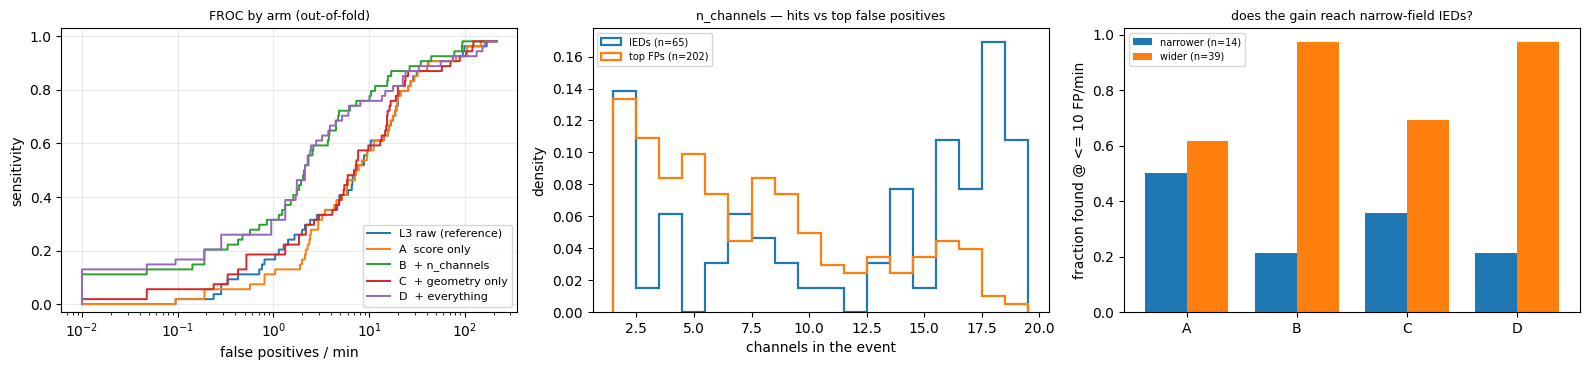

In [ ]:
# L4 spatial features — four arms, off the out-of-fold CV scores. No L3 refitting: the LR that
# combines score + features is fitted inside the SAME folds, so the comparison is paired and leak-free.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.preprocessing import StandardScaler
    from detect_data import electrode_positions
    from detection import _smooth, spatial_features

    NAMES = ['n_channels', 'compactness', 'extent', 'gradient']
    ARMS = {'A  score only': [0], 'B  + n_channels': [0, 1],
            'C  + geometry only': [0, 2, 3, 4], 'D  + everything': [0, 1, 2, 3, 4]}
    Y, G, fold = cv['Y'], cv['G'], cv['fold']

    pos = electrode_positions()
    Xs = {g: _smooth(train[g]['X'], cfg) for g in set(G.tolist())}
    feats = [spatial_features(e, Xs[g], cfg, pos) for e, g in zip(cv['events'], G)]
    F = np.column_stack([cv['scores']] + [np.array([f[n] for f in feats]) for n in NAMES])

    # --- pre-registered univariate screen. Gate: AUC ~0.65 separating hits from FPs ---
    pts3 = M.froc_points(train, cv['events'], G, cv['scores'], cfg)
    topfp = (Y == 0) & (cv['scores'] >= M.threshold_at(pts3, cfg.fp_budget))
    print(f"univariate screen (gate AUC ~0.65) — {Y.sum()} positives, {topfp.sum()} top FPs, "
          f"{(Y == 0).sum()} negatives in the full pool\n")
    print(f"{'feature':<14} {'vs all neg':>11} {'vs top FPs':>11}")
    for j, n in enumerate(NAMES, start=1):
        m = (Y == 1) | topfp
        print(f"{n:<14} {roc_auc_score(Y, F[:, j]):>11.3f} {roc_auc_score(Y[m], F[m, j]):>11.3f}")

    def arm(cols):
        out = np.zeros(len(Y))
        for k in np.unique(fold):
            tr, te = fold != k, fold == k
            sc = StandardScaler().fit(F[np.ix_(tr, cols)])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(F[np.ix_(tr, cols)]), Y[tr])
            out[te] = lr.predict_proba(sc.transform(F[np.ix_(te, cols)]))[:, 1]
        return out

    arms = {'L3 raw (reference)': cv['scores']}
    arms.update({k: arm(v) for k, v in ARMS.items()})

    # --- IED subgroups by field size. The pre-registered <=2-channel group is EMPTY on Kural, so the
    #     narrow group is the bottom quartile: data-defined, and labelled as such wherever it is quoted.
    nch = {}
    for e, g, y, f in zip(cv['events'], G, Y, feats):
        if y == 1:
            nch[g] = max(nch.get(g, 0), f['n_channels'])
    cut = np.percentile(list(nch.values()), 25)
    narrow = {g for g, n in nch.items() if n <= cut}
    wide = set(nch) - narrow
    print(f"\nnarrowest IED spans {min(nch.values())} channels, so the pre-registered <=2-channel "
          f"subgroup is EMPTY.\nbottom quartile (<= {cut:.0f} ch) = {len(narrow)} narrower vs "
          f"{len(wide)} wider IEDs ({len(nch)} of {sum(r['epi'] for r in train)} have a positive event)\n")

    def found(sc, thr, gs):
        best = {}
        for g, y, s in zip(G, Y, sc):
            if y == 1:
                best[g] = max(best.get(g, 0.0), s)
        return sum(best.get(g, 0.0) >= thr for g in gs)

    hdr = (f"{'arm':<20} {'ROC':>6} {'PR':>6} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
           f"{'hits':>5} {'miss':>5} {'FPs':>5} {'narrow':>8} {'wide':>7}")
    print(hdr); print('-' * len(hdr))
    apts, athr = {}, {}
    for name, sc in arms.items():
        apts[name] = M.froc_points(train, cv['events'], G, sc, cfg)
        athr[name] = M.threshold_at(apts[name], cfg.fp_budget)
        su = M.froc_summary(apts[name])
        c = M.detection_counts(train, cv['events'], G, sc, cfg, athr[name])
        print(f"{name:<20} {roc_auc_score(Y, sc):>6.3f} {average_precision_score(Y, sc):>6.3f} "
              f"{su[1]:>5.2f} {su[5]:>5.2f} {su[10]:>5.2f} {su[25]:>5.2f} "
              f"{c['hit']:>5} {c['miss']:>5} {c['fp']:>5} "
              f"{found(sc, athr[name], narrow):>4}/{len(narrow):<3} "
              f"{found(sc, athr[name], wide):>3}/{len(wide):<3}")

    # --- paired bootstrap of the gain, resampling RECORDINGS (the independent unit) ---
    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    base = arms['A  score only']
    print(f"\n{'arm':<20} {'dPR-AUC vs A':>13} {'95% CI':>22} {'P(>0)':>7}")
    for name in list(ARMS)[1:]:
        d = []
        for _ in range(2000):
            take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
            if len(set(Y[take].tolist())) > 1:
                d.append(average_precision_score(Y[take], arms[name][take])
                         - average_precision_score(Y[take], base[take]))
        d = np.array(d)
        obs = average_precision_score(Y, arms[name]) - average_precision_score(Y, base)
        print(f"{name:<20} {obs:>+13.4f} "
              f"{f'[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]':>22} "
              f"{(d > 0).mean():>7.2f}")

    # --- what each arm learned. D's geometry weights are collinear with n_channels: do not read them ---
    print()
    for name, cols in ARMS.items():
        if len(cols) > 1:
            sc = StandardScaler().fit(F[:, cols])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000,
                                    class_weight='balanced').fit(sc.transform(F[:, cols]), Y)
            print(f"{name:<20} " + ', '.join(f"{(['score'] + NAMES)[c]} {w:+.2f}"
                                             for c, w in zip(cols, lr.coef_[0])))

    fig, axs = plt.subplots(1, 3, figsize=(16, 3.8))
    for i, name in enumerate(arms):
        P.froc(axs[0], apts[name], label=name, color=f'C{i}')
    axs[0].set_title('FROC by arm (out-of-fold)', fontsize=9)
    for i, (lbl, m) in enumerate((('IEDs', Y == 1), ('top FPs', topfp))):
        axs[1].hist(F[m, 1], bins=np.arange(1.5, 20.5), histtype='step', lw=1.6, density=True,
                    color=f'C{i}', label=f'{lbl} (n={int(m.sum())})')
    axs[1].set_xlabel('channels in the event'); axs[1].set_ylabel('density')
    axs[1].set_title('n_channels — hits vs top false positives', fontsize=9)
    axs[1].legend(fontsize=7)
    w = 0.38
    for i, (lbl, gs) in enumerate((('narrower', narrow), ('wider', wide))):
        v = [found(arms[a], athr[a], gs) / len(gs) for a in ARMS]
        axs[2].bar(np.arange(len(ARMS)) + i * w, v, w, color=f'C{i}', label=f'{lbl} (n={len(gs)})')
    axs[2].set_xticks(np.arange(len(ARMS)) + w / 2)
    axs[2].set_xticklabels([a.split()[0] for a in ARMS])
    axs[2].set_ylabel(f'fraction found @ <= {cfg.fp_budget:.0f} FP/min')
    axs[2].set_title('does the gain reach narrow-field IEDs?', fontsize=9)
    axs[2].legend(fontsize=7)
    plt.tight_layout()
    plt.savefig('../figures/detection_l4_arms.png', dpi=800, bbox_inches='tight')
    plt.show()


### Is the L4 gain spatial at all, or is it size coming back?

`n_channels` scores univariate ROC **0.797**, and the prominence baseline (§7, no model, no fitting)
scores **0.801**. Two numbers that close, on the same pool, is a strong hint that they are measuring the
same thing — **how big is this event** — rather than anything about its spatial field.

That matters because size was removed deliberately. `normalise_amplitude` divides each window by its
recording's background MAD so L3 judges relative prominence rather than absolute microvolts, adopted on
transfer grounds. If channel count is simply re-admitting magnitude through a different door, then the L4
result is not a spatial finding at all — it is §8 **B** (shape versus size), and it has to be written up
that way.

The test is direct: put prominence in as a feature and see whether it substitutes for `n_channels`,
complements it, or does nothing.

| arm | reads |
|---|---|
| **A** | score alone |
| **B** | score + `n_channels` — the arm to beat, repeated here so the comparison is like-for-like |
| **P1** | score + prominence |
| **P2** | score + both |

**How to read the outcome:**
- **P1 ≈ B and P2 ≈ both** → they are one feature wearing two hats. The L4 result is about size, and the
  honest framing is item B.
- **P2 clearly beats both** → they are complementary: prominence is *amplitude* magnitude and
  `n_channels` is *spatial* magnitude, and the field genuinely adds something.
- **P1 ≪ B** → channel count carries something prominence does not, and the spatial reading survives.

The rank correlation between the two features is printed first, since it largely settles the question
before the arms are fitted.


rank corr(prominence, n_channels): all events +0.332, positives only +0.466

feature         vs all neg  vs top FPs
n_channels           0.810       0.700
prominence           0.805       0.423

arm                     ROC     PR    @1    @5   @10   @25  hits  miss   FPs   narrow    wide
---------------------------------------------------------------------------------------------
L3 raw (reference)    0.853  0.158  0.17  0.41  0.57  0.80    31    23   202    7/14   24/39 
A  score only         0.848  0.135  0.11  0.39  0.57  0.80    31    23   200    7/14   24/39 
B  + n_channels       0.866  0.354  0.31  0.72  0.76  0.87    41    13   155    3/14   38/39 
P1 + prominence       0.850  0.118  0.06  0.39  0.54  0.80    29    25   155    5/14   24/39 
P2 + both             0.865  0.309  0.31  0.70  0.76  0.87    41    13   162    3/14   38/39 

comparison                   dPR-AUC                 95% CI   P(>0)
B vs A                       +0.2186     [+0.1321, +0.3067]    1.00
P1 vs A   

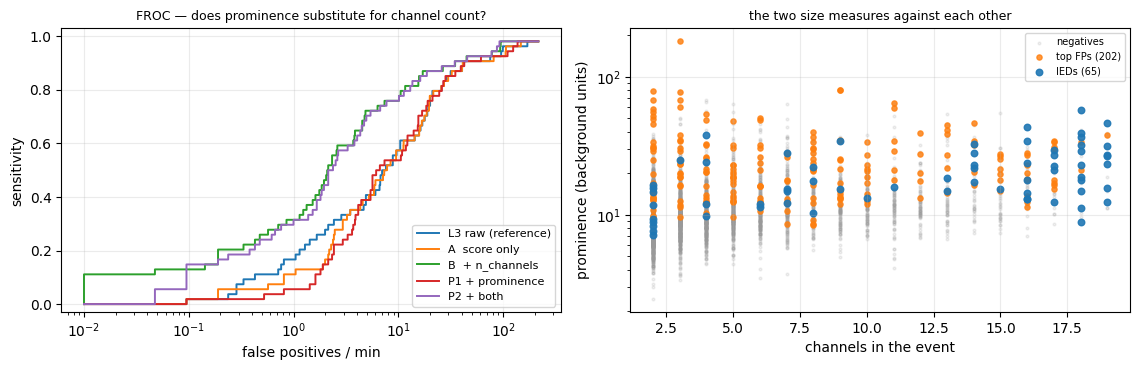

In [ ]:
# Prominence as an L4 feature — is the L4 gain spatial, or is it event size re-entering?
# Uses `cv` from the grouped-CV cell; `pipe` is used only for its L1+L2 pass and window cutting
# (no classifier call), so nothing here crosses a fold boundary.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from scipy.stats import spearmanr
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.preprocessing import StandardScaler

    Y, G, fold = cv['Y'], cv['G'], cv['fold']
    E_, W_, _, _ = M.labelled_events(pipe, train)      # same deterministic order grouped_cv used
    assert [e['time'] for e in E_] == [e['time'] for e in cv['events']], 'event order changed'
    prom = np.ptp(W_, axis=1)                          # windows are already background-normalised
    nch = np.array([e['n_channels'] for e in cv['events']], float)
    F = np.column_stack([cv['scores'], nch, prom])
    ARMS = {'A  score only': [0], 'B  + n_channels': [0, 1],
            'P1 + prominence': [0, 2], 'P2 + both': [0, 1, 2]}

    pts3 = M.froc_points(train, cv['events'], G, cv['scores'], cfg)
    topfp = (Y == 0) & (cv['scores'] >= M.threshold_at(pts3, cfg.fp_budget))
    m = (Y == 1) | topfp
    print(f"rank corr(prominence, n_channels): all events {spearmanr(prom, nch).statistic:+.3f}, "
          f"positives only {spearmanr(prom[Y == 1], nch[Y == 1]).statistic:+.3f}\n")
    print(f"{'feature':<14} {'vs all neg':>11} {'vs top FPs':>11}")
    for j, n in ((1, 'n_channels'), (2, 'prominence')):
        print(f"{n:<14} {roc_auc_score(Y, F[:, j]):>11.3f} {roc_auc_score(Y[m], F[m, j]):>11.3f}")

    def arm(cols):
        out = np.zeros(len(Y))
        for k in np.unique(fold):
            tr, te = fold != k, fold == k
            sc = StandardScaler().fit(F[np.ix_(tr, cols)])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(F[np.ix_(tr, cols)]), Y[tr])
            out[te] = lr.predict_proba(sc.transform(F[np.ix_(te, cols)]))[:, 1]
        return out

    arms = {'L3 raw (reference)': cv['scores']}
    arms.update({k: arm(v) for k, v in ARMS.items()})

    nchm = {}
    for e, g, y in zip(cv['events'], G, Y):
        if y == 1:
            nchm[g] = max(nchm.get(g, 0), e['n_channels'])
    cut = np.percentile(list(nchm.values()), 25)
    narrow = {g for g, n in nchm.items() if n <= cut}
    wide = set(nchm) - narrow

    def found(sc, thr, gs):
        best = {}
        for g, y, s in zip(G, Y, sc):
            if y == 1:
                best[g] = max(best.get(g, 0.0), s)
        return sum(best.get(g, 0.0) >= thr for g in gs)

    hdr = (f"\n{'arm':<20} {'ROC':>6} {'PR':>6} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
           f"{'hits':>5} {'miss':>5} {'FPs':>5} {'narrow':>8} {'wide':>7}")
    print(hdr); print('-' * (len(hdr) - 1))
    apts, athr = {}, {}
    for name, sc in arms.items():
        apts[name] = M.froc_points(train, cv['events'], G, sc, cfg)
        athr[name] = M.threshold_at(apts[name], cfg.fp_budget)
        su = M.froc_summary(apts[name])
        c = M.detection_counts(train, cv['events'], G, sc, cfg, athr[name])
        print(f"{name:<20} {roc_auc_score(Y, sc):>6.3f} {average_precision_score(Y, sc):>6.3f} "
              f"{su[1]:>5.2f} {su[5]:>5.2f} {su[10]:>5.2f} {su[25]:>5.2f} "
              f"{c['hit']:>5} {c['miss']:>5} {c['fp']:>5} "
              f"{found(sc, athr[name], narrow):>4}/{len(narrow):<3} "
              f"{found(sc, athr[name], wide):>3}/{len(wide):<3}")

    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    print(f"\n{'comparison':<26} {'dPR-AUC':>9} {'95% CI':>22} {'P(>0)':>7}")
    for a, b in (('B  + n_channels', 'A  score only'), ('P1 + prominence', 'A  score only'),
                 ('P2 + both', 'A  score only'), ('P2 + both', 'B  + n_channels'),
                 ('P2 + both', 'P1 + prominence')):
        d = []
        for _ in range(2000):
            take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
            if len(set(Y[take].tolist())) > 1:
                d.append(average_precision_score(Y[take], arms[a][take])
                         - average_precision_score(Y[take], arms[b][take]))
        d = np.array(d)
        obs = average_precision_score(Y, arms[a]) - average_precision_score(Y, arms[b])
        print(f"{a.split()[0] + ' vs ' + b.split()[0]:<26} {obs:>+9.4f} "
              f"{f'[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]':>22} "
              f"{(d > 0).mean():>7.2f}")

    print()
    for name, cols in ARMS.items():
        if len(cols) > 1:
            sc = StandardScaler().fit(F[:, cols])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000,
                                    class_weight='balanced').fit(sc.transform(F[:, cols]), Y)
            print(f"{name:<20} " + ', '.join(f"{['score', 'n_channels', 'prominence'][c]} {w:+.2f}"
                                             for c, w in zip(cols, lr.coef_[0])))

    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.8))
    for i, name in enumerate(arms):
        P.froc(axs[0], apts[name], label=name, color=f'C{i}')
    axs[0].set_title('FROC — does prominence substitute for channel count?', fontsize=9)
    axs[1].scatter(nch[Y == 0], prom[Y == 0], s=4, alpha=0.15, color='0.6', label='negatives')
    axs[1].scatter(nch[topfp], prom[topfp], s=14, alpha=0.8, color='C1', label=f'top FPs ({topfp.sum()})')
    axs[1].scatter(nch[Y == 1], prom[Y == 1], s=22, alpha=0.9, color='C0', label=f'IEDs ({Y.sum()})')
    axs[1].set_yscale('log'); axs[1].set_xlabel('channels in the event')
    axs[1].set_ylabel('prominence (background units)')
    axs[1].set_title('the two size measures against each other', fontsize=9)
    axs[1].legend(fontsize=7); axs[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig('../figures/detection_l4_prominence.png', dpi=800, bbox_inches='tight')
    plt.show()


### Arms E and F — binning, and a size-free field measure

Prominence turned out **not** to substitute for `n_channels`, so the L4 gain is spatial rather than
magnitude re-entering. These two arms probe that mechanism directly, and each targets a specific defect
in the first four arms.

**E — bin `n_channels` instead of using it linearly.** A linear term asserts that 19 channels is ~9.5×
as IED-like as 2, which is wrong at exactly the end that matters: a focal discharge can legitimately
occupy the floor of `min_channels = 2`. Bins let that mode carry its own coefficient rather than the
worst point on a line. Edges are anatomical, **not** read off the enrichment table — that table comes
from the same 60 positives, so choosing edges from it would bake selection into the feature:

| bin | reading |
|---|---|
| `2` | the floor — a focal discharge at its narrowest |
| `3–7` | a lobar / regional field (**reference level**, so coefficients read as "versus regional") |
| `≥8` | more than a third of the montage — hemispheric or bilateral |

**F — mean nearest-neighbour distance, replacing compactness and extent.** Both of those failed as
size-free measures because both grow with channel count, and their ratio is exactly 0.5 for every
2-channel event, i.e. blank for ~35% of the pool. Nearest-neighbour distance — for each member, the
distance to the closest *other* member, averaged — asks "is this a contiguous patch?" independently of
how large the patch is. Measured on the montage: a contiguous field scores ~60 mm whether it spans 2, 3
or 5 channels, while a scattered pair (F7 + O2) scores 185 mm.

**This is the first feature that can reward a focal pair rather than penalise it for being small**, which
is the question the earlier arms could not answer: narrow-field IEDs sat at 6/13 in every one of them.

*Known limitation:* nearest-neighbour distance measures **local** contiguity, not global connectedness.
Two tight but separate clusters — a genuine bilateral discharge, or a coincidence of two artefacts —
score the same as one patch. If F wins, a spatial-cluster-count feature is the natural follow-up; it is
deliberately not being added now.

**The row to read is the narrow/wide subgroup**, not the headline. F is the arm that could move it.

Selection note: with the first four arms, the prominence arms and these three, roughly eleven
configurations have now been compared on the same 49 IEDs. Whatever is adopted is a choice made on the
100 recordings CV and must be reported as such, with the losing arms shown alongside.


univariate (nn_distance is inverted by design: contiguous = LOW = more IED-like)

feature         vs all neg  vs top FPs                 IEDs            top FPs
n_channels           0.810       0.700       14.0 [7,18]        6.5 [4,10]
nn_distance          0.359       0.343       60.8 [61,62]       63.0 [61,76]

k=2 events: 34.8% of the pool, 13.8% of IEDs; their median nn_distance is 69 mm for IEDs vs 83 mm for top FPs

arm                     ROC     PR    @1    @5   @10   @25  hits  miss   FPs   narrow    wide
---------------------------------------------------------------------------------------------
L3 raw (reference)    0.853  0.158  0.17  0.41  0.57  0.80    31    23   202    7/14   24/39 
A  score only         0.848  0.135  0.11  0.39  0.57  0.80    31    23   200    7/14   24/39 
B  + n_channels       0.866  0.354  0.31  0.72  0.76  0.87    41    13   155    3/14   38/39 
E  + binned k         0.866  0.190  0.15  0.52  0.72  0.89    39    15   194    4/14   35/39 
F  + nn_dis

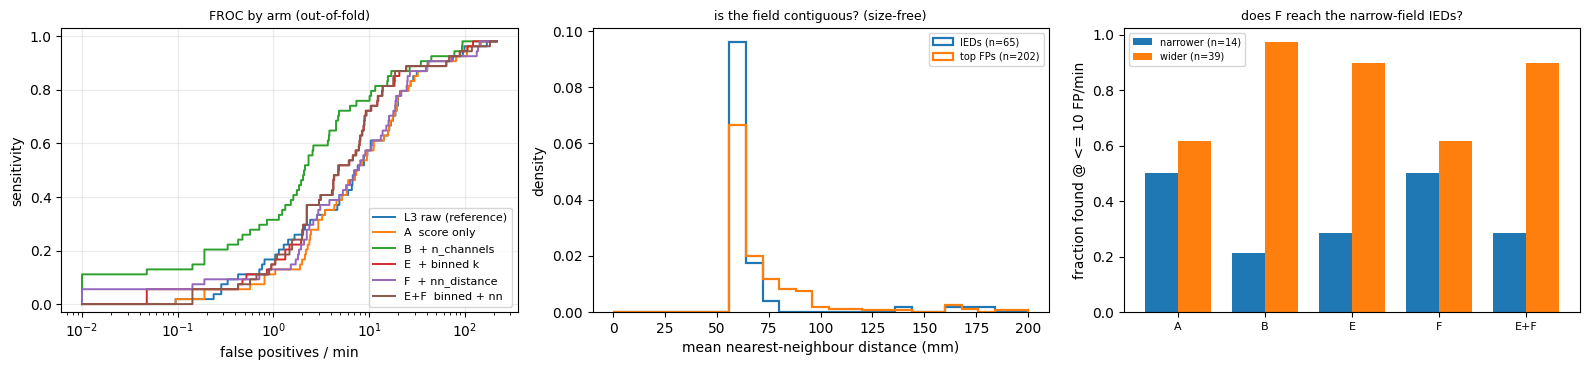

In [ ]:
# Arms E (binned n_channels) and F (size-free nearest-neighbour distance), plus both.
# Uses `cv` from the grouped-CV cell; the combining LR is fitted inside the SAME folds.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.preprocessing import StandardScaler
    from detect_data import electrode_positions
    from detection import _smooth, spatial_features

    Y, G, fold = cv['Y'], cv['G'], cv['fold']
    pos = electrode_positions()
    Xs = {g: _smooth(train[g]['X'], cfg) for g in set(G.tolist())}
    feats = [spatial_features(e, Xs[g], cfg, pos) for e, g in zip(cv['events'], G)]

    k = np.array([f['n_channels'] for f in feats], float)
    nn = np.array([f['nn_distance'] for f in feats])
    F = np.column_stack([cv['scores'], k, (k <= 2).astype(float), (k >= 8).astype(float), nn])
    COLS = ['score', 'n_channels', 'k=2', 'k>=8', 'nn_distance']
    ARMS = {'A  score only': [0], 'B  + n_channels': [0, 1], 'E  + binned k': [0, 2, 3],
            'F  + nn_distance': [0, 4], 'E+F  binned + nn': [0, 2, 3, 4]}

    pts3 = M.froc_points(train, cv['events'], G, cv['scores'], cfg)
    topfp = (Y == 0) & (cv['scores'] >= M.threshold_at(pts3, cfg.fp_budget))
    m = (Y == 1) | topfp
    print("univariate (nn_distance is inverted by design: contiguous = LOW = more IED-like)\n")
    print(f"{'feature':<14} {'vs all neg':>11} {'vs top FPs':>11}   {'IEDs':>18} {'top FPs':>18}")
    for j in (1, 4):
        v = F[:, j]
        print(f"{COLS[j]:<14} {roc_auc_score(Y, v):>11.3f} {roc_auc_score(Y[m], v[m]):>11.3f}   "
              f"{np.median(v[Y == 1]):>8.1f} [{np.percentile(v[Y==1],25):.0f},{np.percentile(v[Y==1],75):.0f}]"
              f"   {np.median(v[topfp]):>8.1f} [{np.percentile(v[topfp],25):.0f},{np.percentile(v[topfp],75):.0f}]")
    print(f"\nk=2 events: {(k <= 2).mean():.1%} of the pool, {(k[Y == 1] <= 2).mean():.1%} of IEDs; "
          f"their median nn_distance is {np.median(nn[(k <= 2) & (Y == 1)]):.0f} mm for IEDs vs "
          f"{np.median(nn[(k <= 2) & topfp]):.0f} mm for top FPs")

    def arm(cols):
        out = np.zeros(len(Y))
        for kf in np.unique(fold):
            tr, te = fold != kf, fold == kf
            sc = StandardScaler().fit(F[np.ix_(tr, cols)])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(F[np.ix_(tr, cols)]), Y[tr])
            out[te] = lr.predict_proba(sc.transform(F[np.ix_(te, cols)]))[:, 1]
        return out

    arms = {'L3 raw (reference)': cv['scores']}
    arms.update({name: arm(cols) for name, cols in ARMS.items()})

    nchm = {}
    for e, g, y in zip(cv['events'], G, Y):
        if y == 1:
            nchm[g] = max(nchm.get(g, 0), e['n_channels'])
    cut = np.percentile(list(nchm.values()), 25)
    narrow = {g for g, n in nchm.items() if n <= cut}
    wide = set(nchm) - narrow

    def found(sc, thr, gs):
        best = {}
        for g, y, s in zip(G, Y, sc):
            if y == 1:
                best[g] = max(best.get(g, 0.0), s)
        return sum(best.get(g, 0.0) >= thr for g in gs)

    hdr = (f"\n{'arm':<20} {'ROC':>6} {'PR':>6} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
           f"{'hits':>5} {'miss':>5} {'FPs':>5} {'narrow':>8} {'wide':>7}")
    print(hdr); print('-' * (len(hdr) - 1))
    apts, athr = {}, {}
    for name, sc in arms.items():
        apts[name] = M.froc_points(train, cv['events'], G, sc, cfg)
        athr[name] = M.threshold_at(apts[name], cfg.fp_budget)
        su = M.froc_summary(apts[name])
        c = M.detection_counts(train, cv['events'], G, sc, cfg, athr[name])
        print(f"{name:<20} {roc_auc_score(Y, sc):>6.3f} {average_precision_score(Y, sc):>6.3f} "
              f"{su[1]:>5.2f} {su[5]:>5.2f} {su[10]:>5.2f} {su[25]:>5.2f} "
              f"{c['hit']:>5} {c['miss']:>5} {c['fp']:>5} "
              f"{found(sc, athr[name], narrow):>4}/{len(narrow):<3} "
              f"{found(sc, athr[name], wide):>3}/{len(wide):<3}")

    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    print(f"\n{'comparison':<26} {'dPR-AUC':>9} {'95% CI':>22} {'P(>0)':>7}")
    for a, b in (('E  + binned k', 'B  + n_channels'), ('F  + nn_distance', 'A  score only'),
                 ('F  + nn_distance', 'B  + n_channels'), ('E+F  binned + nn', 'B  + n_channels')):
        d = []
        for _ in range(2000):
            take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
            if len(set(Y[take].tolist())) > 1:
                d.append(average_precision_score(Y[take], arms[a][take])
                         - average_precision_score(Y[take], arms[b][take]))
        d = np.array(d)
        obs = average_precision_score(Y, arms[a]) - average_precision_score(Y, arms[b])
        print(f"{a.split()[0] + ' vs ' + b.split()[0]:<26} {obs:>+9.4f} "
              f"{f'[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]':>22} "
              f"{(d > 0).mean():>7.2f}")

    print()
    for name, cols in ARMS.items():
        if len(cols) > 1:
            sc = StandardScaler().fit(F[:, cols])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000,
                                    class_weight='balanced').fit(sc.transform(F[:, cols]), Y)
            print(f"{name:<20} " + ', '.join(f"{COLS[c]} {w:+.2f}" for c, w in zip(cols, lr.coef_[0])))

    fig, axs = plt.subplots(1, 3, figsize=(16, 3.8))
    for i, name in enumerate(arms):
        P.froc(axs[0], apts[name], label=name, color=f'C{i}')
    axs[0].set_title('FROC by arm (out-of-fold)', fontsize=9)
    for i, (lbl, sel) in enumerate((('IEDs', Y == 1), ('top FPs', topfp))):
        axs[1].hist(nn[sel], bins=np.linspace(0, 200, 26), histtype='step', lw=1.6, density=True,
                    color=f'C{i}', label=f'{lbl} (n={int(sel.sum())})')
    axs[1].set_xlabel('mean nearest-neighbour distance (mm)'); axs[1].set_ylabel('density')
    axs[1].set_title('is the field contiguous? (size-free)', fontsize=9); axs[1].legend(fontsize=7)
    w = 0.38
    for i, (lbl, gs) in enumerate((('narrower', narrow), ('wider', wide))):
        v = [found(arms[a], athr[a], gs) / len(gs) for a in ARMS]
        axs[2].bar(np.arange(len(ARMS)) + i * w, v, w, color=f'C{i}', label=f'{lbl} (n={len(gs)})')
    axs[2].set_xticks(np.arange(len(ARMS)) + w / 2)
    axs[2].set_xticklabels([a.split()[0] for a in ARMS], fontsize=8)
    axs[2].set_ylabel(f'fraction found @ <= {cfg.fp_budget:.0f} FP/min')
    axs[2].set_title('does F reach the narrow-field IEDs?', fontsize=9); axs[2].legend(fontsize=7)
    plt.tight_layout()
    plt.savefig('../figures/detection_l4_arms_ef.png', dpi=800, bbox_inches='tight')
    plt.show()


### Error analysis for arm B (score + `n_channels`)

Arm B won on every axis that matters and is the candidate for adoption. Before adopting it, the same
questions Phase 1 asked of L3 have to be asked of B — a doubled PR-AUC says the ranking improved, not
that it improved for defensible reasons.

**Q1–Q4 repeat Phase 1 side by side with L3**, so any change is visible rather than inferred: hits and
misses by neurologist certainty, the cost in extra false positives of reaching each missed IED, how
concentrated the false positives are across recordings, and the epileptic vs non-epileptic FP rate.

**Q5–Q8 exist only because a scorer is being swapped**, and they are the reason this cell is not just
Phase 1 re-run:

- **Q5 — who actually changed?** B finds 39 IEDs against L3's 33. A net +6 could be +6/−0 or +8/−2, and
  those mean very different things. An IED that L3 found and B lost is a regression that a headline
  number hides.
- **Q6 — are they even the same false positives?** B raises 183 FPs against L3's 181. Nearly the same
  count could still be near-total churn, which would mean B is a different model rather than a refined
  one. Kept / removed / newly-introduced are counted separately.
- **Q7 — what survives?** B demotes low-channel events by construction, so the surviving false positives
  should be the wide-field ones. Confirming that names the next lever: whatever still outranks an IED
  after spatial spread is accounted for.
- **Q8 — the narrow-field misses, individually.** Narrow-field IEDs sat at 6/13 in all nine arms. This
  lists the seven that are still missed with their certainty, best score and field size, since an
  aggregate that never moves is exactly the thing to look at case by case.

**A note on what adoption costs**, not an argument against it: B changes every score the pipeline
produces, so the pre-registered 0.80 threshold, the shipped `detect_model.joblib` and the pilot CSVs
already returned all refer to the L3-only scorer and would need re-deriving.


operating points — L3 score >= 0.840, arm B score >= 0.797 (both at <= 10 FP/min)

                                             L3        arm B
Q1  hits / misses by certainty
      clear_positive               12/22 (55%)  16/22 (73%)
      unclear_positive             19/32 (59%)  25/32 (78%)
Q2  cost of reaching a missed IED (extra FPs)
      median                              +444         +558
      reachable (<= 50 FPs)                  0            0
      unreachable (> 500 FPs)               11            7
Q3  false-positive concentration
      recordings affected                   71           64
      share in worst 9 recordings 32% in worst 9 32% in worst 9
Q4  FP rate, epileptic vs non-epileptic
      epileptic                        9.7/min      7.6/min
      non-epileptic                    9.4/min      7.1/min

Q5  who changed?  31 -> 41 IEDs found (+14 gained, -4 LOST)
      gained  S27    unclear_positive   18 ch   L3 0.814 -> B 0.939
      gained  S09    clear_positi

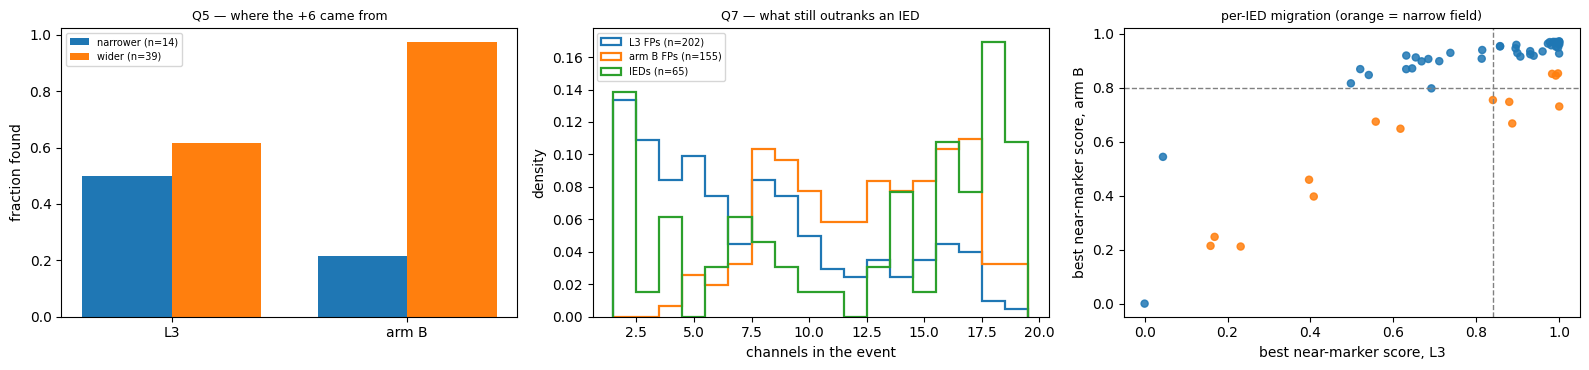

In [ ]:
# Error analysis for arm B (score + n_channels), out-of-fold, at the <= 10 FP/min operating point.
# Pure bookkeeping on the CV scores — no refitting of L3.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    Y, G, fold, tol = cv['Y'], cv['G'], cv['fold'], cfg.samp(cfg.hit_tol_ms)
    nch = np.array([e['n_channels'] for e in cv['events']], float)
    F = np.column_stack([cv['scores'], nch])

    sB = np.zeros(len(Y))
    for k in np.unique(fold):
        tr, te = fold != k, fold == k
        sc = StandardScaler().fit(F[tr])
        lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
        lr.fit(sc.transform(F[tr]), Y[tr])
        sB[te] = lr.predict_proba(sc.transform(F[te]))[:, 1]

    KEYS = ('L3', 'B')
    S = {'L3': cv['scores'], 'B': sB}
    thr = {k: M.threshold_at(M.froc_points(train, cv['events'], G, S[k], cfg), cfg.fp_budget)
           for k in KEYS}
    epi = [g for g, r in enumerate(train) if r['epi']]

    best, fps, nonhit = {}, {}, {}
    for k in KEYS:
        best[k], fps[k], nonhit[k] = {}, set(), []
        for i, (e, g, s) in enumerate(zip(cv['events'], G, S[k])):
            r = train[g]
            if r['epi'] and abs(e['time'] - r['mk']) <= tol:
                best[k][g] = max(best[k].get(g, 0.0), s)
            else:
                nonhit[k].append(s)
                if s >= thr[k]:
                    fps[k].add(i)
        nonhit[k] = np.array(nonhit[k])
    hit = {k: {g for g in epi if best[k].get(g, 0.0) >= thr[k]} for k in KEYS}
    print(f"operating points — L3 score >= {thr['L3']:.3f}, arm B score >= {thr['B']:.3f} "
          f"(both at <= {cfg.fp_budget:.0f} FP/min)\n")

    print(f"{'':<34} {'L3':>12} {'arm B':>12}")
    print("Q1  hits / misses by certainty")
    for c in ('clear_positive', 'unclear_positive'):
        gs = [g for g in epi if train[g]['cert'] == c]
        cells = [f"{len(hit[k] & set(gs))}/{len(gs)} ({len(hit[k] & set(gs)) / len(gs):.0%})" for k in S]
        print(f"      {c:<28}{cells[0]:>12} {cells[1]:>12}")

    print("Q2  cost of reaching a missed IED (extra FPs)")
    cost = {k: sorted(int((nonhit[k] > best[k].get(g, 0.0)).sum()) for g in epi if g not in hit[k])
            for k in KEYS}
    med = {k: '+' + str(int(np.median(v))) for k, v in cost.items()}
    print(f"      {'median':<28}{med['L3']:>12} {med['B']:>12}")
    for lbl, f in (('reachable (<= 50 FPs)', lambda c: sum(x <= 50 for x in c)),
                   ('unreachable (> 500 FPs)', lambda c: sum(x > 500 for x in c))):
        print(f"      {lbl:<28}{f(cost['L3']):>12} {f(cost['B']):>12}")

    print("Q3  false-positive concentration")
    conc = {}
    for k in KEYS:
        per = {}
        for i in fps[k]:
            per[G[i]] = per.get(G[i], 0) + 1
        c = np.array(sorted(per.values(), reverse=True))
        conc[k] = f"{c[:9].sum() / c.sum():.0%} in worst 9"
    print(f"      {'recordings affected':<28}{len({G[i] for i in fps['L3']}):>12} "
          f"{len({G[i] for i in fps['B']}):>12}")
    print(f"      {'share in worst 9 recordings':<28}{conc['L3']:>12} {conc['B']:>12}")

    print("Q4  FP rate, epileptic vs non-epileptic")
    for lbl, sel in (('epileptic', True), ('non-epileptic', False)):
        gs = {g for g, r in enumerate(train) if r['epi'] == sel}
        mins = sum(train[g]['dur'] for g in gs) / 60.0
        rates = {k: f"{sum(1 for i in fps[k] if G[i] in gs) / mins:.1f}/min" for k in KEYS}
        print(f"      {lbl:<28}{rates['L3']:>12} {rates['B']:>12}")

    gained, lost = hit['B'] - hit['L3'], hit['L3'] - hit['B']
    print(f"\nQ5  who changed?  {len(hit['L3'])} -> {len(hit['B'])} IEDs found "
          f"(+{len(gained)} gained, -{len(lost)} LOST)")
    for lbl, gs in (('gained', gained), ('LOST', lost)):
        for g in sorted(gs, key=lambda g: -best['B'].get(g, 0.0)):
            mx = max((e['n_channels'] for e, gg, y in zip(cv['events'], G, Y)
                      if gg == g and y == 1), default=0)
            print(f"      {lbl:<7} {train[g]['fid']:<6} {train[g]['cert']:<18} "
                  f"{mx:>2} ch   L3 {best['L3'].get(g, 0.0):.3f} -> B {best['B'].get(g, 0.0):.3f}")

    kept, removed, new = fps['L3'] & fps['B'], fps['L3'] - fps['B'], fps['B'] - fps['L3']
    print(f"\nQ6  false-positive churn: {len(fps['L3'])} -> {len(fps['B'])}   "
          f"kept {len(kept)}, removed {len(removed)}, NEW {len(new)} "
          f"({len(kept) / max(len(fps['B']), 1):.0%} of B's FPs were already L3's)")

    print(f"\nQ7  what the surviving false positives look like (median channels per event)")
    print(f"      {'L3 FPs':<28}{np.median(nch[list(fps['L3'])]):>12.0f} ch")
    print(f"      {'arm B FPs':<28}{np.median(nch[list(fps['B'])]):>12.0f} ch")
    if removed:
        print(f"      {'removed by B':<28}{np.median(nch[list(removed)]):>12.0f} ch")
    if new:
        print(f"      {'newly introduced by B':<28}{np.median(nch[list(new)]):>12.0f} ch")
    print(f"      {'the IEDs themselves':<28}{np.median(nch[Y == 1]):>12.0f} ch")

    nchm = {}
    for e, g, y in zip(cv['events'], G, Y):
        if y == 1:
            nchm[g] = max(nchm.get(g, 0), e['n_channels'])
    cut = np.percentile(list(nchm.values()), 25)
    narrow = {g for g, n in nchm.items() if n <= cut}
    print(f"\nQ8  narrow-field IEDs (<= {cut:.0f} ch) still missed by arm B — "
          f"{len(narrow - hit['B'])} of {len(narrow)}")
    for g in sorted(narrow - hit['B'], key=lambda g: -best['B'].get(g, 0.0)):
        print(f"      {train[g]['fid']:<6} {train[g]['cert']:<18} {nchm[g]:>2} ch   "
              f"L3 {best['L3'].get(g, 0.0):.3f} -> B {best['B'].get(g, 0.0):.3f}   "
              f"(threshold {thr['B']:.3f})")

    fig, axs = plt.subplots(1, 3, figsize=(16, 3.8))
    wide = set(nchm) - narrow
    x = np.arange(2)
    for i, (lbl, gs) in enumerate((('narrower', narrow), ('wider', wide))):
        axs[0].bar(x + i * 0.38, [len(hit[k] & gs) / len(gs) for k in ('L3', 'B')], 0.38,
                   color=f'C{i}', label=f'{lbl} (n={len(gs)})')
    axs[0].set_xticks(x + 0.19); axs[0].set_xticklabels(['L3', 'arm B'])
    axs[0].set_ylabel('fraction found'); axs[0].legend(fontsize=7)
    axs[0].set_title('Q5 — where the +6 came from', fontsize=9)
    for i, (lbl, sel) in enumerate((('L3 FPs', list(fps['L3'])), ('arm B FPs', list(fps['B'])),
                                    ('IEDs', np.where(Y == 1)[0]))):
        axs[1].hist(nch[sel], bins=np.arange(1.5, 20.5), histtype='step', lw=1.6, density=True,
                    color=f'C{i}', label=f'{lbl} (n={len(sel)})')
    axs[1].set_xlabel('channels in the event'); axs[1].set_ylabel('density')
    axs[1].set_title('Q7 — what still outranks an IED', fontsize=9); axs[1].legend(fontsize=7)
    col = ['C1' if g in narrow else 'C0' for g in epi]
    axs[2].scatter([best['L3'].get(g, 0.0) for g in epi], [best['B'].get(g, 0.0) for g in epi],
                   c=col, s=26, alpha=0.85)
    axs[2].axvline(thr['L3'], color='0.5', ls='--', lw=1.0)
    axs[2].axhline(thr['B'], color='0.5', ls='--', lw=1.0)
    axs[2].set_xlabel('best near-marker score, L3'); axs[2].set_ylabel('best near-marker score, arm B')
    axs[2].set_title('per-IED migration (orange = narrow field)', fontsize=9)
    plt.tight_layout()
    plt.savefig('../figures/detection_l4_error_analysis.png', dpi=800, bbox_inches='tight')
    plt.show()


### Three more spatial features — dipole, propagation, symmetry

Arm B (score + `n_channels`) is adopted, and after it the surviving false positives are wide, contiguous
and prominent — indistinguishable from IEDs on every axis measured so far (median 11 channels against the
IEDs' 14). Extent is exhausted. What remains unused is **sign and timing structure across the field**.

| feature | what it asks | why it might separate what B cannot |
|---|---|---|
| `dipole` | distance between the positive- and negative-member centroids, over the extent | L2 groups on `\|correlation\|`, so member **sign is computed and discarded**. A real IED is a dipole — two spatially coherent poles. Muscle and movement scatter. |
| `propagation` | rank correlation of member time against distance from the earliest member | A focal discharge travels outward; volume-conducted artefact is simultaneous. |
| `symmetry` | mean over the 8 homologous L/R pairs of `1 - \|L-R\|/(L+R)` | The survivors are *wide*, and wide artefact (chewing, movement, EMG) is typically one-sided, while a generalized discharge is bilaterally synchronous by definition. |

**One nuance the dipole feature is built around:** an average reference forces the field to sum to zero,
so nearly every event has both signs present. The question is therefore not "are both signs there" but
"are they spatially **organised**" — hence centroid separation rather than a sign count.

**And one prediction stated in advance, so it can be wrong:** `propagation` will probably come out null.
`coincidence_ms = 50` caps an event's total time spread at 50 ms, which is 12 samples at 250 Hz, and L1's
peak picking quantises further. There may simply not be enough dynamic range to carry a gradient.

Arms are kept to five and all are reported. B is the baseline every comparison is made against — not
arm A — because B is what is currently adopted, so the question is what these add *on top of* it. The
narrow/wide subgroup row stays on every line: it has sat at 6/13 through nine arms.


univariate screen — 65 positives, 202 top FPs, 4543 negatives

feature        vs all neg  vs top FPs     IEDs median  top FP median
n_channels          0.810       0.700          14.000          6.500
dipole              0.515       0.503           0.513          0.522
propagation         0.481       0.400           0.250          0.397
symmetry            0.779       0.701           0.529          0.228

zero-valued (feature undefined for that event): dipole 29%, propagation 40%, symmetry 62%

arm                     ROC     PR    @1    @5   @10   @25  hits  miss   FPs   narrow    wide
---------------------------------------------------------------------------------------------
L3 raw (reference)    0.853  0.158  0.17  0.41  0.57  0.80    31    23   202    7/14   24/39 
B   score+n_chan      0.866  0.354  0.31  0.72  0.76  0.87    41    13   155    3/14   38/39 
B+D  dipole           0.865  0.363  0.35  0.70  0.80  0.87    43    11   198    5/14   38/39 
B+T  propagation      0.864  0

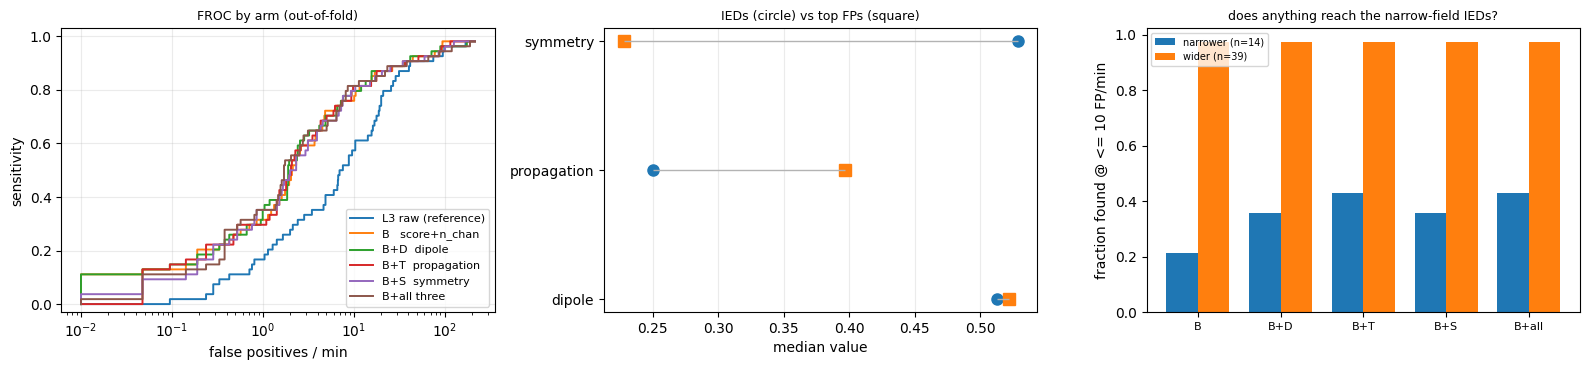

In [ ]:
# Dipole / propagation / symmetry, on top of the adopted arm B. Uses `cv` from the grouped-CV cell.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.preprocessing import StandardScaler
    from detect_data import electrode_positions
    from detection import _smooth, spatial_features

    Y, G, fold = cv['Y'], cv['G'], cv['fold']
    pos = electrode_positions()
    Xs = {g: _smooth(train[g]['X'], cfg) for g in set(G.tolist())}
    feats = [spatial_features(e, Xs[g], cfg, pos) for e, g in zip(cv['events'], G)]

    NEW = ['dipole', 'propagation', 'symmetry']
    COLS = ['score', 'n_channels'] + NEW
    F = np.column_stack([cv['scores'], [f['n_channels'] for f in feats]]
                        + [[f[n] for f in feats] for n in NEW])
    ARMS = {'B   score+n_chan': [0, 1], 'B+D  dipole': [0, 1, 2],
            'B+T  propagation': [0, 1, 3], 'B+S  symmetry': [0, 1, 4],
            'B+all three': [0, 1, 2, 3, 4]}

    pts3 = M.froc_points(train, cv['events'], G, cv['scores'], cfg)
    topfp = (Y == 0) & (cv['scores'] >= M.threshold_at(pts3, cfg.fp_budget))
    m = (Y == 1) | topfp
    print(f"univariate screen — {Y.sum()} positives, {topfp.sum()} top FPs, {(Y == 0).sum()} negatives\n")
    print(f"{'feature':<13} {'vs all neg':>11} {'vs top FPs':>11}   {'IEDs median':>13} {'top FP median':>14}")
    for j, n in enumerate(COLS):
        if j == 0:
            continue
        v = F[:, j]
        print(f"{n:<13} {roc_auc_score(Y, v):>11.3f} {roc_auc_score(Y[m], v[m]):>11.3f}   "
              f"{np.median(v[Y == 1]):>13.3f} {np.median(v[topfp]):>14.3f}")
    print(f"\nzero-valued (feature undefined for that event): "
          + ', '.join(f"{n} {np.mean(F[:, COLS.index(n)] == 0):.0%}" for n in NEW))

    def arm(cols):
        out = np.zeros(len(Y))
        for k in np.unique(fold):
            tr, te = fold != k, fold == k
            sc = StandardScaler().fit(F[np.ix_(tr, cols)])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(F[np.ix_(tr, cols)]), Y[tr])
            out[te] = lr.predict_proba(sc.transform(F[np.ix_(te, cols)]))[:, 1]
        return out

    arms = {'L3 raw (reference)': cv['scores']}
    arms.update({name: arm(cols) for name, cols in ARMS.items()})

    nchm = {}
    for e, g, y in zip(cv['events'], G, Y):
        if y == 1:
            nchm[g] = max(nchm.get(g, 0), e['n_channels'])
    cut = np.percentile(list(nchm.values()), 25)
    narrow = {g for g, n in nchm.items() if n <= cut}
    wide = set(nchm) - narrow

    def found(sc, thr, gs):
        best = {}
        for g, y, s in zip(G, Y, sc):
            if y == 1:
                best[g] = max(best.get(g, 0.0), s)
        return sum(best.get(g, 0.0) >= thr for g in gs)

    hdr = (f"\n{'arm':<20} {'ROC':>6} {'PR':>6} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
           f"{'hits':>5} {'miss':>5} {'FPs':>5} {'narrow':>8} {'wide':>7}")
    print(hdr); print('-' * (len(hdr) - 1))
    apts, athr = {}, {}
    for name, sc in arms.items():
        apts[name] = M.froc_points(train, cv['events'], G, sc, cfg)
        athr[name] = M.threshold_at(apts[name], cfg.fp_budget)
        su = M.froc_summary(apts[name])
        c = M.detection_counts(train, cv['events'], G, sc, cfg, athr[name])
        print(f"{name:<20} {roc_auc_score(Y, sc):>6.3f} {average_precision_score(Y, sc):>6.3f} "
              f"{su[1]:>5.2f} {su[5]:>5.2f} {su[10]:>5.2f} {su[25]:>5.2f} "
              f"{c['hit']:>5} {c['miss']:>5} {c['fp']:>5} "
              f"{found(sc, athr[name], narrow):>4}/{len(narrow):<3} "
              f"{found(sc, athr[name], wide):>3}/{len(wide):<3}")

    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    base = arms['B   score+n_chan']
    print(f"\n{'arm':<20} {'dPR-AUC vs B':>13} {'95% CI':>22} {'P(>0)':>7}")
    for name in list(ARMS)[1:]:
        d = []
        for _ in range(2000):
            take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
            if len(set(Y[take].tolist())) > 1:
                d.append(average_precision_score(Y[take], arms[name][take])
                         - average_precision_score(Y[take], base[take]))
        d = np.array(d)
        obs = average_precision_score(Y, arms[name]) - average_precision_score(Y, base)
        print(f"{name:<20} {obs:>+13.4f} "
              f"{f'[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]':>22} "
              f"{(d > 0).mean():>7.2f}")

    print()
    for name, cols in ARMS.items():
        sc = StandardScaler().fit(F[:, cols])
        lr = LogisticRegression(C=cfg.lr_C, max_iter=1000,
                                class_weight='balanced').fit(sc.transform(F[:, cols]), Y)
        print(f"{name:<20} " + ', '.join(f"{COLS[c]} {w:+.2f}" for c, w in zip(cols, lr.coef_[0])))

    fig, axs = plt.subplots(1, 3, figsize=(16, 3.8))
    for i, name in enumerate(arms):
        P.froc(axs[0], apts[name], label=name, color=f'C{i}')
    axs[0].set_title('FROC by arm (out-of-fold)', fontsize=9)
    for i, n in enumerate(NEW):
        v = F[:, COLS.index(n)]
        axs[1].plot([np.median(v[Y == 1])], [i], 'o', color='C0', ms=8)
        axs[1].plot([np.median(v[topfp])], [i], 's', color='C1', ms=8)
        axs[1].hlines(i, min(np.median(v[Y == 1]), np.median(v[topfp])),
                      max(np.median(v[Y == 1]), np.median(v[topfp])), color='0.7', lw=1)
    axs[1].set_yticks(range(len(NEW))); axs[1].set_yticklabels(NEW)
    axs[1].set_xlabel('median value'); axs[1].grid(alpha=0.25, axis='x')
    axs[1].set_title('IEDs (circle) vs top FPs (square)', fontsize=9)
    w = 0.38
    for i, (lbl, gs) in enumerate((('narrower', narrow), ('wider', wide))):
        v = [found(arms[a], athr[a], gs) / len(gs) for a in ARMS]
        axs[2].bar(np.arange(len(ARMS)) + i * w, v, w, color=f'C{i}', label=f'{lbl} (n={len(gs)})')
    axs[2].set_xticks(np.arange(len(ARMS)) + w / 2)
    axs[2].set_xticklabels([a.split()[0] for a in ARMS], fontsize=8)
    axs[2].set_ylabel(f'fraction found @ <= {cfg.fp_budget:.0f} FP/min')
    axs[2].set_title('does anything reach the narrow-field IEDs?', fontsize=9); axs[2].legend(fontsize=7)
    plt.tight_layout()
    plt.savefig('../figures/detection_l4_dipole_timing_symmetry.png', dpi=800, bbox_inches='tight')
    plt.show()


### Nonlinearity, and a control on the dipole feature

**Amended after the first run.** `logit(score)` was tested and **lost** — ΔPR-AUC −0.080 against the raw
probability, P(>0) = 0.06. Worth recording why, because it is not obvious: logit gave the *best* ROC
(0.877) and by far the fewest false positives (119), but the worst PR-AUC and @1 FP/min. It stretches the
easy-negative mass across ~14 units of range and spends the model's linear capacity there. The raw
probability's saturation near zero is doing useful work precisely because 98.5% of the pool is trivial
negatives. It is kept below as a single row, as a documented negative.

Consequently **the two nonlinear arms now sit on the raw-score base**, not the logit one — in the first
run they were only ever tested on top of a baseline that was itself inferior, so neither had a fair
evaluation.

| arm | question |
|---|---|
| `B    score+k` | the currently adopted baseline |
| `B+D  +dipole` | the candidate addition |
| `B+Di +dipole>0` | **the control** — does the dipole's *value* matter, or only that it is defined? |
| `Bl   logit+k` | retained as the documented loser |
| `B+D+k2` | linear `n_channels` plus a single `k = 2` offset — the minimal fix arm E argued for |
| `B+D+int` | `score x n_channels` — does spread matter more when L3 is uncertain? |

**On the control**, which is the one that decides whether dipole is adoptable: `dipole` has no univariate
signal (0.520) and is exactly zero for 29% of events, so it could plausibly be acting as a
defined/undefined indicator rather than a measurement. Replacing the value with the binary tests that
directly. In the first run the binary's coefficient collapsed to **+0.02** against the value's **+0.29**,
and the binary arm was worse on every axis — so the magnitude carries the information. It stays in the
table so that comparison remains visible rather than asserted.

**Watch the narrow-field column on `B+D+k2`.** On the logit base it *raised* PR-AUC significantly
(+0.019, P = 0.99) while dropping the narrow subgroup 7/13 → 4/13 and losing 3 hits — it improved the
number it was scored on and damaged the thing it was designed to fix. If that repeats on the raw base it
is a reject regardless of ΔPR-AUC.


dipole is zero for 29% of events, k<=2 for 35%

arm                        ROC     PR    @1    @5   @10   @25  hits  miss   FPs   narrow    wide
------------------------------------------------------------------------------------------------
L3 raw (reference)       0.853  0.158  0.17  0.41  0.57  0.80    31    23   202    7/14   24/39 
B    score+k             0.866  0.354  0.31  0.72  0.76  0.87    41    13   155    3/14   38/39 
B+D  +dipole             0.865  0.363  0.35  0.70  0.80  0.87    43    11   198    5/14   38/39 
B+Di +dipole>0           0.856  0.328  0.31  0.69  0.76  0.87    41    13   154    3/14   38/39 
Bl   logit+k             0.870  0.273  0.28  0.74  0.78  0.89    42    12   197    4/14   38/39 
B+D+k2   +k=2 dummy      0.877  0.383  0.35  0.69  0.76  0.87    41    13   168    3/14   38/39 
B+D+int  +score x k      0.852  0.331  0.39  0.65  0.78  0.87    42    12   179    4/14   38/39 

comparison                                 dPR-AUC                 95% CI   P(

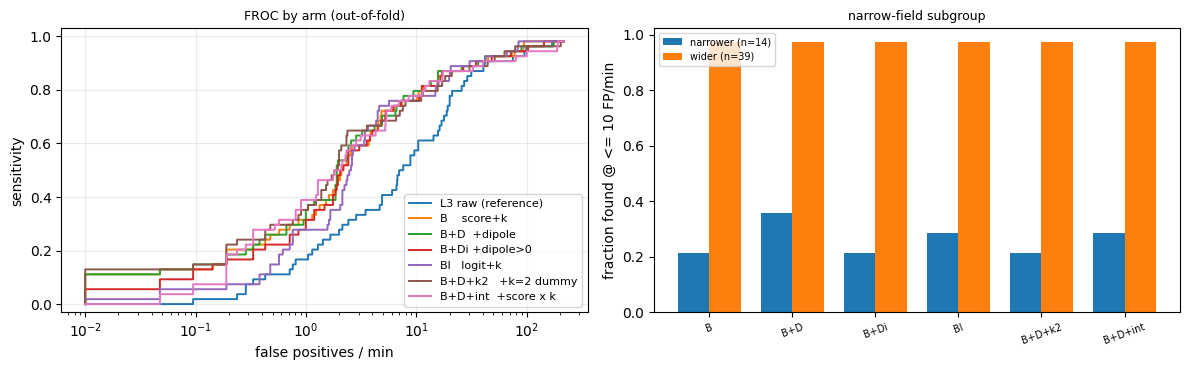

In [ ]:
# Nonlinearity on the RAW-score base (logit lost), plus the dipole defined/undefined control.
if 'cv' not in globals():
    print('Run the grouped-CV cell above with RUN_GROUPED_CV = True first — this uses its scores.')
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import average_precision_score, roc_auc_score
    from sklearn.preprocessing import StandardScaler
    from detect_data import electrode_positions
    from detection import _smooth, spatial_features

    Y, G, fold = cv['Y'], cv['G'], cv['fold']
    pos = electrode_positions()
    Xs = {g: _smooth(train[g]['X'], cfg) for g in set(G.tolist())}
    feats = [spatial_features(e, Xs[g], cfg, pos) for e, g in zip(cv['events'], G)]

    s = cv['scores']
    logit = np.log(np.clip(s, 1e-6, 1 - 1e-6) / (1 - np.clip(s, 1e-6, 1 - 1e-6)))
    k = np.array([f['n_channels'] for f in feats], float)
    dip = np.array([f['dipole'] for f in feats])
    COLS = ['score', 'logit', 'n_channels', 'dipole', 'dipole>0', 'k=2', 'score x k']
    F = np.column_stack([s, logit, k, dip, (dip > 0).astype(float), (k <= 2).astype(float), s * k])
    ARMS = {'B    score+k': [0, 2], 'B+D  +dipole': [0, 2, 3], 'B+Di +dipole>0': [0, 2, 4],
            'Bl   logit+k': [1, 2], 'B+D+k2   +k=2 dummy': [0, 2, 3, 5],
            'B+D+int  +score x k': [0, 2, 3, 6]}
    PAIRS = [('B+D  +dipole', 'B    score+k'), ('B+D  +dipole', 'B+Di +dipole>0'),
             ('Bl   logit+k', 'B    score+k'), ('B+D+k2   +k=2 dummy', 'B+D  +dipole'),
             ('B+D+int  +score x k', 'B+D  +dipole')]

    print(f"dipole is zero for {(dip == 0).mean():.0%} of events, k<=2 for {(k <= 2).mean():.0%}\n")

    def arm(cols):
        out = np.zeros(len(Y))
        for kf in np.unique(fold):
            tr, te = fold != kf, fold == kf
            sc = StandardScaler().fit(F[np.ix_(tr, cols)])
            lr = LogisticRegression(C=cfg.lr_C, max_iter=1000, class_weight='balanced')
            lr.fit(sc.transform(F[np.ix_(tr, cols)]), Y[tr])
            out[te] = lr.predict_proba(sc.transform(F[np.ix_(te, cols)]))[:, 1]
        return out

    arms = {'L3 raw (reference)': s}
    arms.update({name: arm(cols) for name, cols in ARMS.items()})

    nchm = {}
    for e, g, y in zip(cv['events'], G, Y):
        if y == 1:
            nchm[g] = max(nchm.get(g, 0), e['n_channels'])
    cut = np.percentile(list(nchm.values()), 25)
    narrow = {g for g, n in nchm.items() if n <= cut}
    wide = set(nchm) - narrow

    def found(sc, thr, gs):
        best = {}
        for g, y, v in zip(G, Y, sc):
            if y == 1:
                best[g] = max(best.get(g, 0.0), v)
        return sum(best.get(g, 0.0) >= thr for g in gs)

    hdr = (f"{'arm':<23} {'ROC':>6} {'PR':>6} {'@1':>5} {'@5':>5} {'@10':>5} {'@25':>5} "
           f"{'hits':>5} {'miss':>5} {'FPs':>5} {'narrow':>8} {'wide':>7}")
    print(hdr); print('-' * len(hdr))
    apts, athr = {}, {}
    for name, sc in arms.items():
        apts[name] = M.froc_points(train, cv['events'], G, sc, cfg)
        athr[name] = M.threshold_at(apts[name], cfg.fp_budget)
        su = M.froc_summary(apts[name])
        c = M.detection_counts(train, cv['events'], G, sc, cfg, athr[name])
        print(f"{name:<23} {roc_auc_score(Y, sc):>6.3f} {average_precision_score(Y, sc):>6.3f} "
              f"{su[1]:>5.2f} {su[5]:>5.2f} {su[10]:>5.2f} {su[25]:>5.2f} "
              f"{c['hit']:>5} {c['miss']:>5} {c['fp']:>5} "
              f"{found(sc, athr[name], narrow):>4}/{len(narrow):<3} "
              f"{found(sc, athr[name], wide):>3}/{len(wide):<3}")

    rng, groups = np.random.default_rng(0), np.unique(G)
    idx = {g: np.where(G == g)[0] for g in groups}
    print(f"\n{'comparison':<40} {'dPR-AUC':>9} {'95% CI':>22} {'P(>0)':>7}")
    for a, b in PAIRS:
        d = []
        for _ in range(2000):
            take = np.concatenate([idx[g] for g in rng.choice(groups, len(groups), replace=True)])
            if len(set(Y[take].tolist())) > 1:
                d.append(average_precision_score(Y[take], arms[a][take])
                         - average_precision_score(Y[take], arms[b][take]))
        d = np.array(d)
        obs = average_precision_score(Y, arms[a]) - average_precision_score(Y, arms[b])
        print(f"{a.split()[0] + ' vs ' + b.split()[0]:<40} {obs:>+9.4f} "
              f"{f'[{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]':>22} "
              f"{(d > 0).mean():>7.2f}")

    print()
    for name, cols in ARMS.items():
        sc = StandardScaler().fit(F[:, cols])
        lr = LogisticRegression(C=cfg.lr_C, max_iter=1000,
                                class_weight='balanced').fit(sc.transform(F[:, cols]), Y)
        print(f"{name:<23} " + ', '.join(f"{COLS[c]} {w:+.2f}" for c, w in zip(cols, lr.coef_[0])))

    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
    for i, name in enumerate(arms):
        P.froc(axs[0], apts[name], label=name, color=f'C{i}')
    axs[0].set_title('FROC by arm (out-of-fold)', fontsize=9)
    w = 0.38
    for i, (lbl, gs) in enumerate((('narrower', narrow), ('wider', wide))):
        v = [found(arms[a], athr[a], gs) / len(gs) for a in ARMS]
        axs[1].bar(np.arange(len(ARMS)) + i * w, v, w, color=f'C{i}', label=f'{lbl} (n={len(gs)})')
    axs[1].set_xticks(np.arange(len(ARMS)) + w / 2)
    axs[1].set_xticklabels([a.split()[0] for a in ARMS], fontsize=7, rotation=20)
    axs[1].set_ylabel(f'fraction found @ <= {cfg.fp_budget:.0f} FP/min')
    axs[1].set_title('narrow-field subgroup', fontsize=9); axs[1].legend(fontsize=7)
    plt.tight_layout()
    plt.savefig('../figures/detection_l4_nonlinear.png', dpi=800, bbox_inches='tight')
    plt.show()
